# Простые методы предсказания ВР

## Содержание



|раздел | [Nixtla](https://nixtlaverse.nixtla.io/statsforecast/) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/)| [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|QuickStart| [statsforecast](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_short.html)/[end2end tour](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_complete.html#train-multiple-models-for-many-series)/ [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/getting-started/getting_Started_short.ipynb) [GitHub2](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/getting-started/getting_Started_complete.ipynb)| [Chp1](https://otexts.com/fpppy/nbs/01-intro.html), [5.1](https://otexts.com/fpppy/nbs/05-toolbox.html)|
|Naive |    [models_intro](https://nixtlaverse.nixtla.io/statsforecast/src/core/models_intro.html)   | [5.2](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-simple-methods)|
|ExpSmooth | [automatic_forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html),/[ETS at scale](https://nixtlaverse.nixtla.io/statsforecast/docs/experiments/ets_ray_m5.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/models/AutoETS.ipynb)| [Chapter 8](https://otexts.com/fpppy/nbs/08-exponential-smoothing.html)|
|STL | [MSTL](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/multipleseasonalities.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/MultipleSeasonalities.ipynb)  |[3.6](https://otexts.com/fpppy/nbs/03-decomposition.html#sec-stl), [5.7](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-forecasting-decomposition), [12.1](https://otexts.com/fpppy/nbs/12-advanced.html#sec-complexseasonality)|
|Prophet|    [forecast-function-using-prophet](https://nixtlaverse.nixtla.io/statsforecast/docs/experiments/prophet_spark_m5.html#forecast-function-using-prophet) [GitHub](https://github.com/Nixtla/statsforecast/tree/main/nbs/docs/experiments) | [12.2](https://otexts.com/fpppy/nbs/12-advanced.html#sec-prophet) |

* [Effortless Accuracy Unlocking the Power of Baseline Forecasts](https://www.nixtla.io/blog/baseline-forecasts)
* [Out-of-Sample Time Series Forecasting (TSF) via Auto models](https://readmedium.com/out-of-sample-time-series-forecasting-tsf-via-nixtlas-statsforecast-autoarima-autoets-0e163a22d9cb)
* [Automatic Time Series Forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/how-to-guides/Automatic_Forecasting.ipynb)
* [Auto models selection statforecast](https://www.nixtla.io/blog/statsforecast-automatic-model-selection)
* [arima_prophet_adapter](https://github.com/Nixtla/statsforecast/blob/main/experiments/arima_prophet_adapter/README.md)
* [StatForecast in AutoGluno using](https://readmedium.com/autogluon-timeseries-every-time-series-forecasting-model-in-one-library-29a3bf6879db)

## Библиотеки экосистемы анализа временных рядов Nixtla 

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [73]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape, mase, coverage, quantile_loss

In [44]:
from TSC_Nixtla_dump import *
plt_style_GOST()

### Загрузка данных

Загрузим данные

In [45]:
df_ = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df_.head(1)

,Consumption,Wind,Solar,temperature,radiation_direct_horizontal,hour,month,day_of_week,Consumption_detrended,season,day_of_week_str,daylight_duration,week,is_holiday,Consumption_resid,Wind_resid,Solar_resid,temperature_resid,radiation_direct_horizontal_resid
time,,,,,,,,,,,,,,,,,,,
2015-01-01,41.151,8.852,0.071,-0.981,0.0,0,1,3,-7.29271,Winter,Thu,7.921998,1,True,0.136794,0.610749,0.382488,-4.475639,-7.584582


Выберем ВР для дальнейшего анализа

In [46]:
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']

Для простоты освоения инструментов возьмам данные только с самым длинным периодом. То есть усредрим все более быстрые колебания. Данные будем рассматривать с шагом в неделю. У нас остается 1 сезонная компонента со значением сезона - 53 недели (1 год)

In [47]:
y = df_.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
})

y = y.iloc[1:-2]

### Приведение данных к long формату

#### Преобразуем временной ряд к стандартному для `Nixtla` виду `panel`. 

Такой формат данных это по сути т.н. long данные - когда все ВР составлены в столбец. И каждый ВР выбирается по уникальному идентификатору.

Для этого создадим соответствующие столбцы:
* `ds` - временные метки.
* `unique_id` - название временного ряда. Это будет полезно при использовании многопеременных или иерархических временных рядов.
* `y` - целевая переменная ВР. В случае ногопеременных или иерархических временных рядов метки будут разделяться по их `unique_id`.

Такой формат [с укажанием id каждой записи](https://nixtlaverse.nixtla.io/neuralforecast/examples/data_format.html) представления временных рядов известен как [<tt>long format</tt>](https://www.theanalysisfactor.com/wide-and-long-data/).

In [48]:
ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

,unique_id,ds,y
145,Consumption,2017-10-22,9501.628
346,Wind,2016-09-11,574.938
271,Wind,2015-04-05,2449.821
14,Consumption,2015-04-19,8967.627
230,Consumption,2019-06-09,9160.731


#### ВР
Проверим, что у нас действительно все датасеты  

In [49]:
panel_df['unique_id'].unique()

array(['Consumption', 'Wind', 'Solar'], dtype=object)

#### Получим частоту для дальнейшей работы

In [50]:
FREQ = y.index.freq
FREQ

<Week: weekday=6>

#### Проверим значенипе сезонности при помощи утилиты `find_season_length`

In [51]:
from coreforecast.seasonal import find_season_length

In [52]:
SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON

52

#### экзогенные переменные

Также попробуем добавить экзогенные переменные. Они будут добавляться как дополнительные столбцы где для будут дублироваться для каждого `'unique_id'` по сопостовлению временных меток `ds`

In [53]:
df_exog = y[exog_cols].reset_index()
df_exog['ds'] = date_index
panel_df = panel_df.merge(df_exog, on='ds', how='left')
panel_df = panel_df[[*base_cols, *exog_cols]]
panel_df = panel_df.rename(columns = {'radiation_direct_horizontal':'radiation'})

panel_df.head(2)

,unique_id,ds,y,temperature,radiation
0,Consumption,2015-01-11,9440.105,2.488536,5.554645
1,Consumption,2015-01-18,9689.010,3.012375,7.504608


### Визуализация Временных рядов

#### plot_series
Для визуализации ВР воспользуемся функцией [`plot_series`](https://nixtlaverse.nixtla.io/utilsforecast/plotting.html#plot-series) из библиотеки [`utilsforecast`](https://nixtlaverse.nixtla.io/utilsforecast). Функция имеет несколько "движков", в зависимости от них настройки будут разными. 

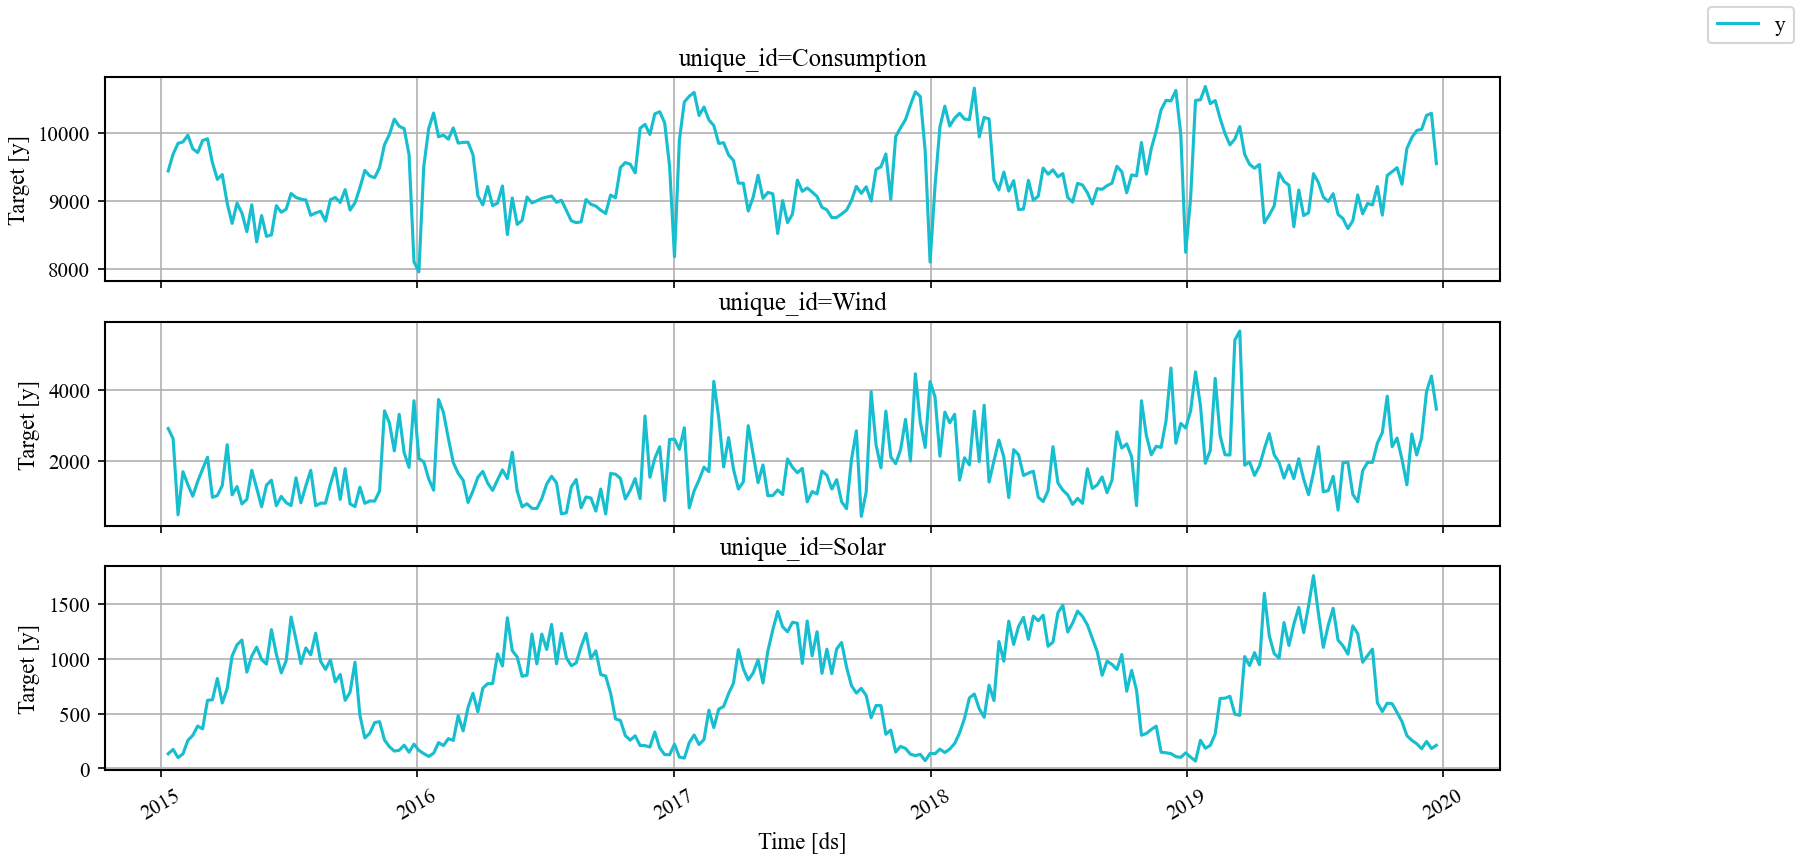

In [54]:
n_rows = len(panel_df['unique_id'].unique())
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)
plot_series(panel_df, ax = ax)

#### Мы будем использовать иногда функцию plot_series_v2

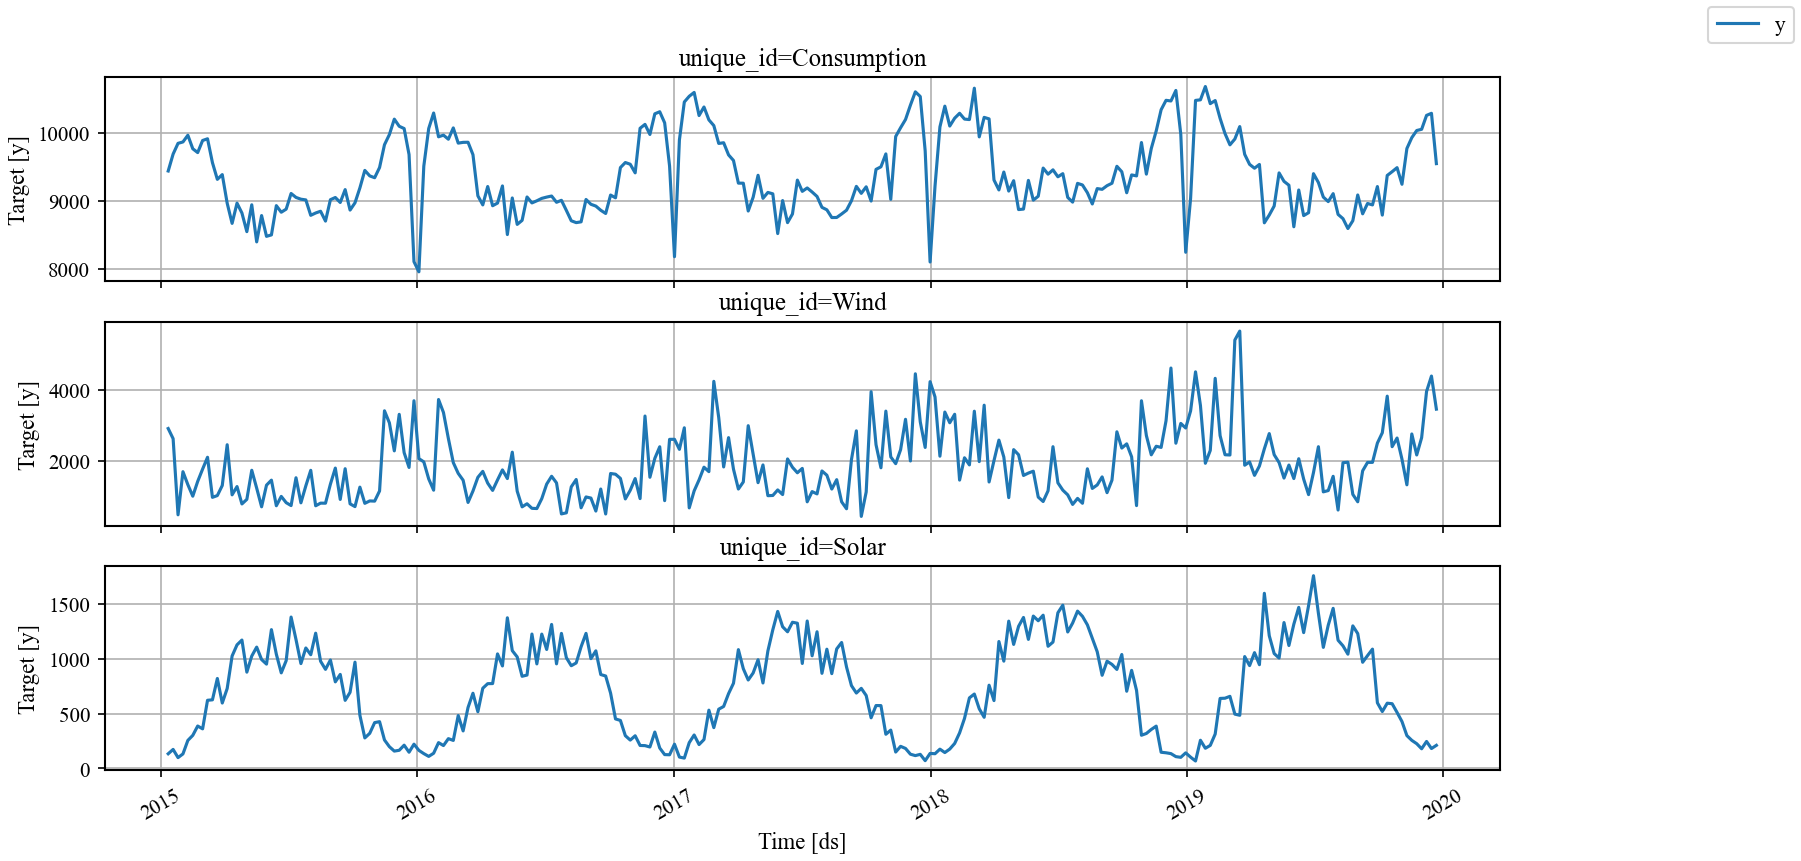

In [55]:
plot_series_v2(panel_df)

### Train Test Split

Разделим ВР на тренировочную и тестовую части. К сожалению на сегодня это возможно только в ручном режиме

In [56]:
FH = int(0.42 * y.shape[0])

In [57]:
df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

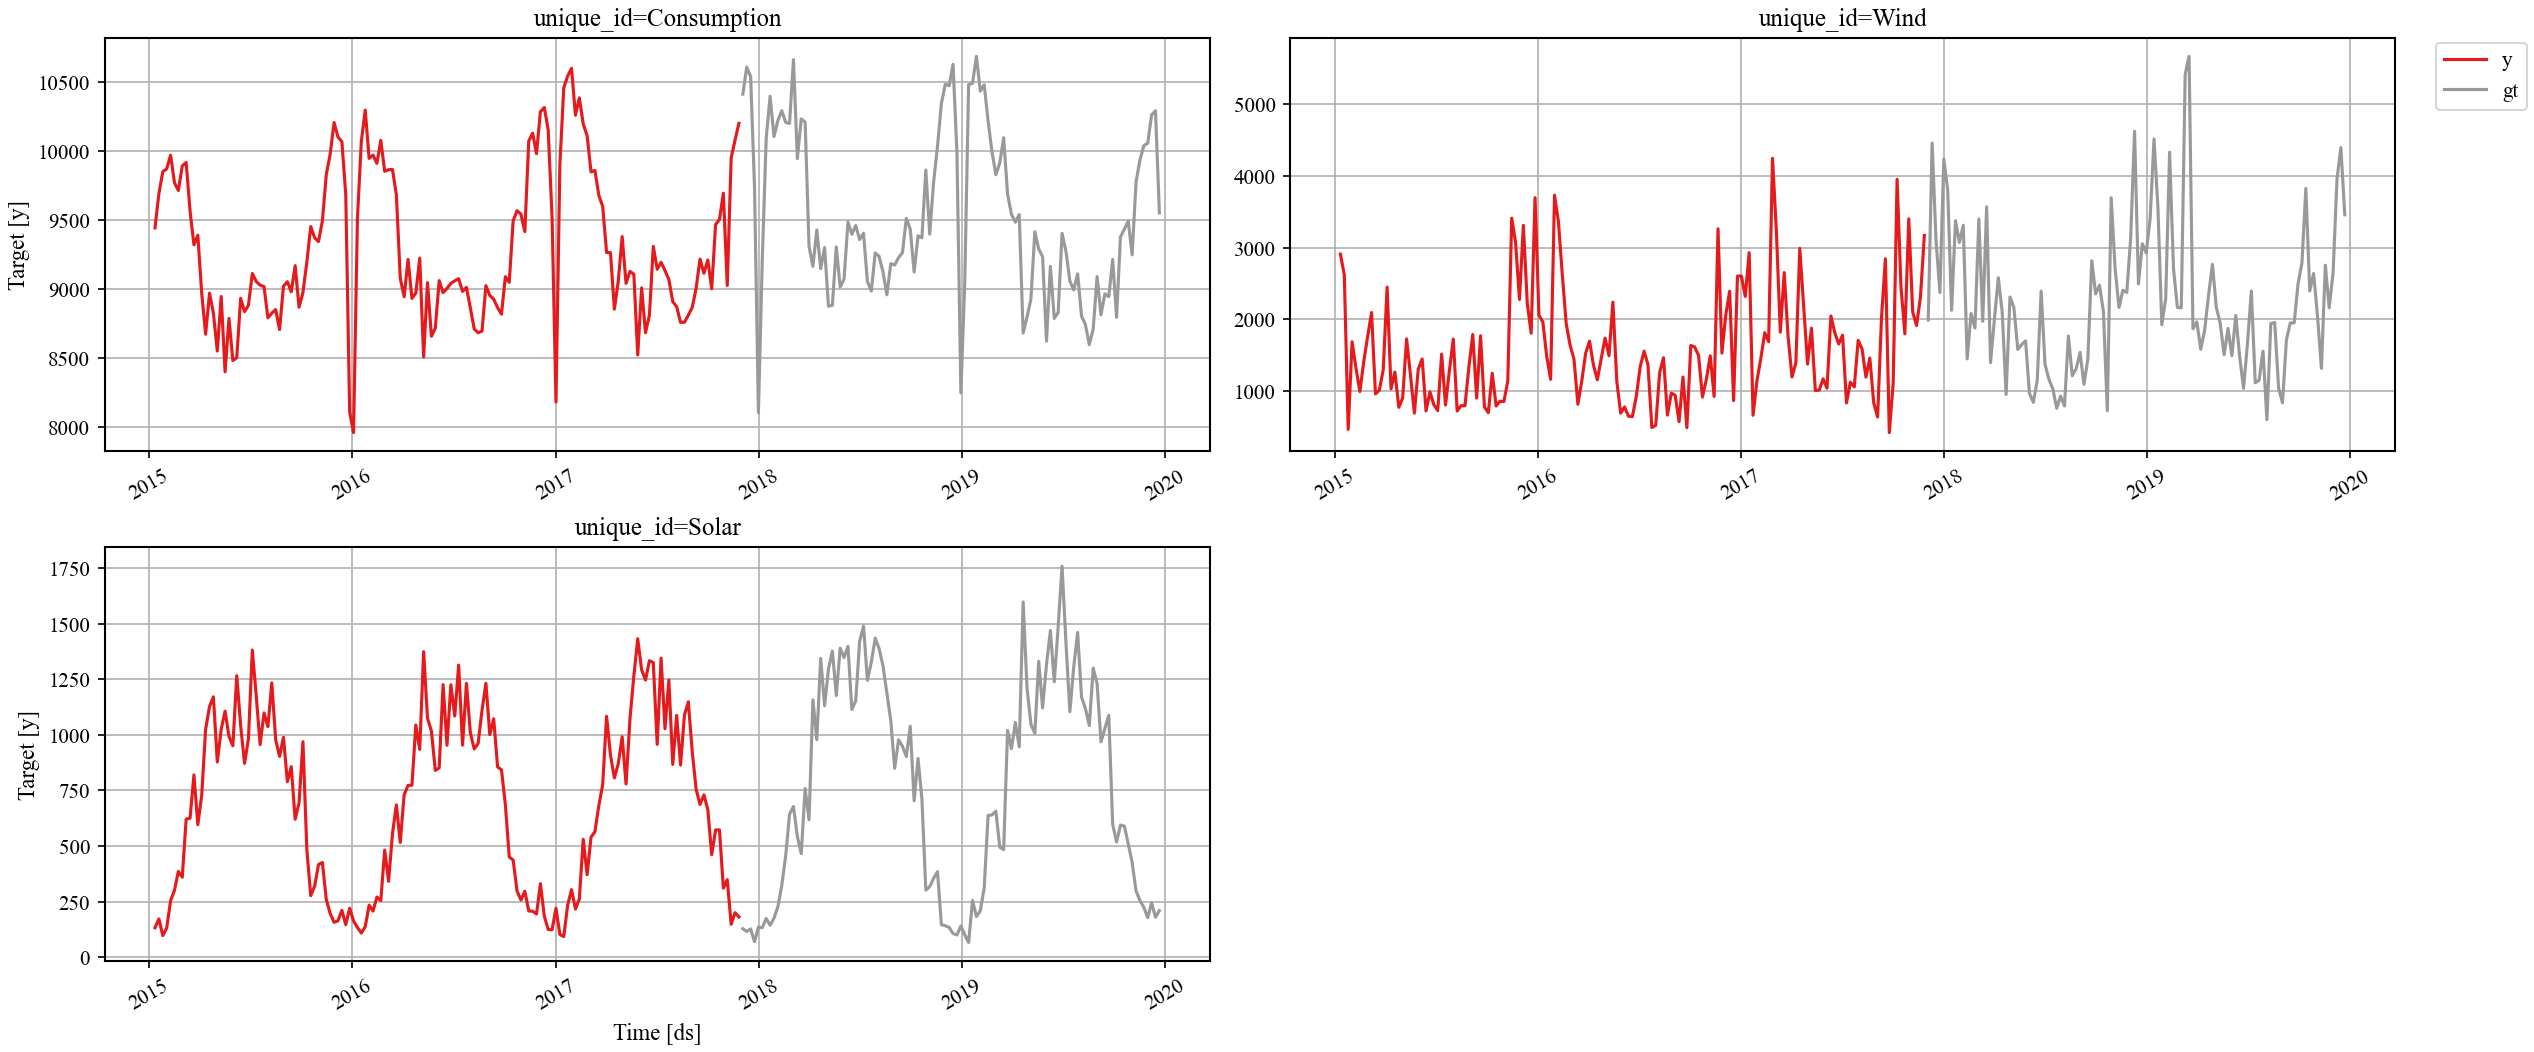

In [58]:
plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

## Дополнительно

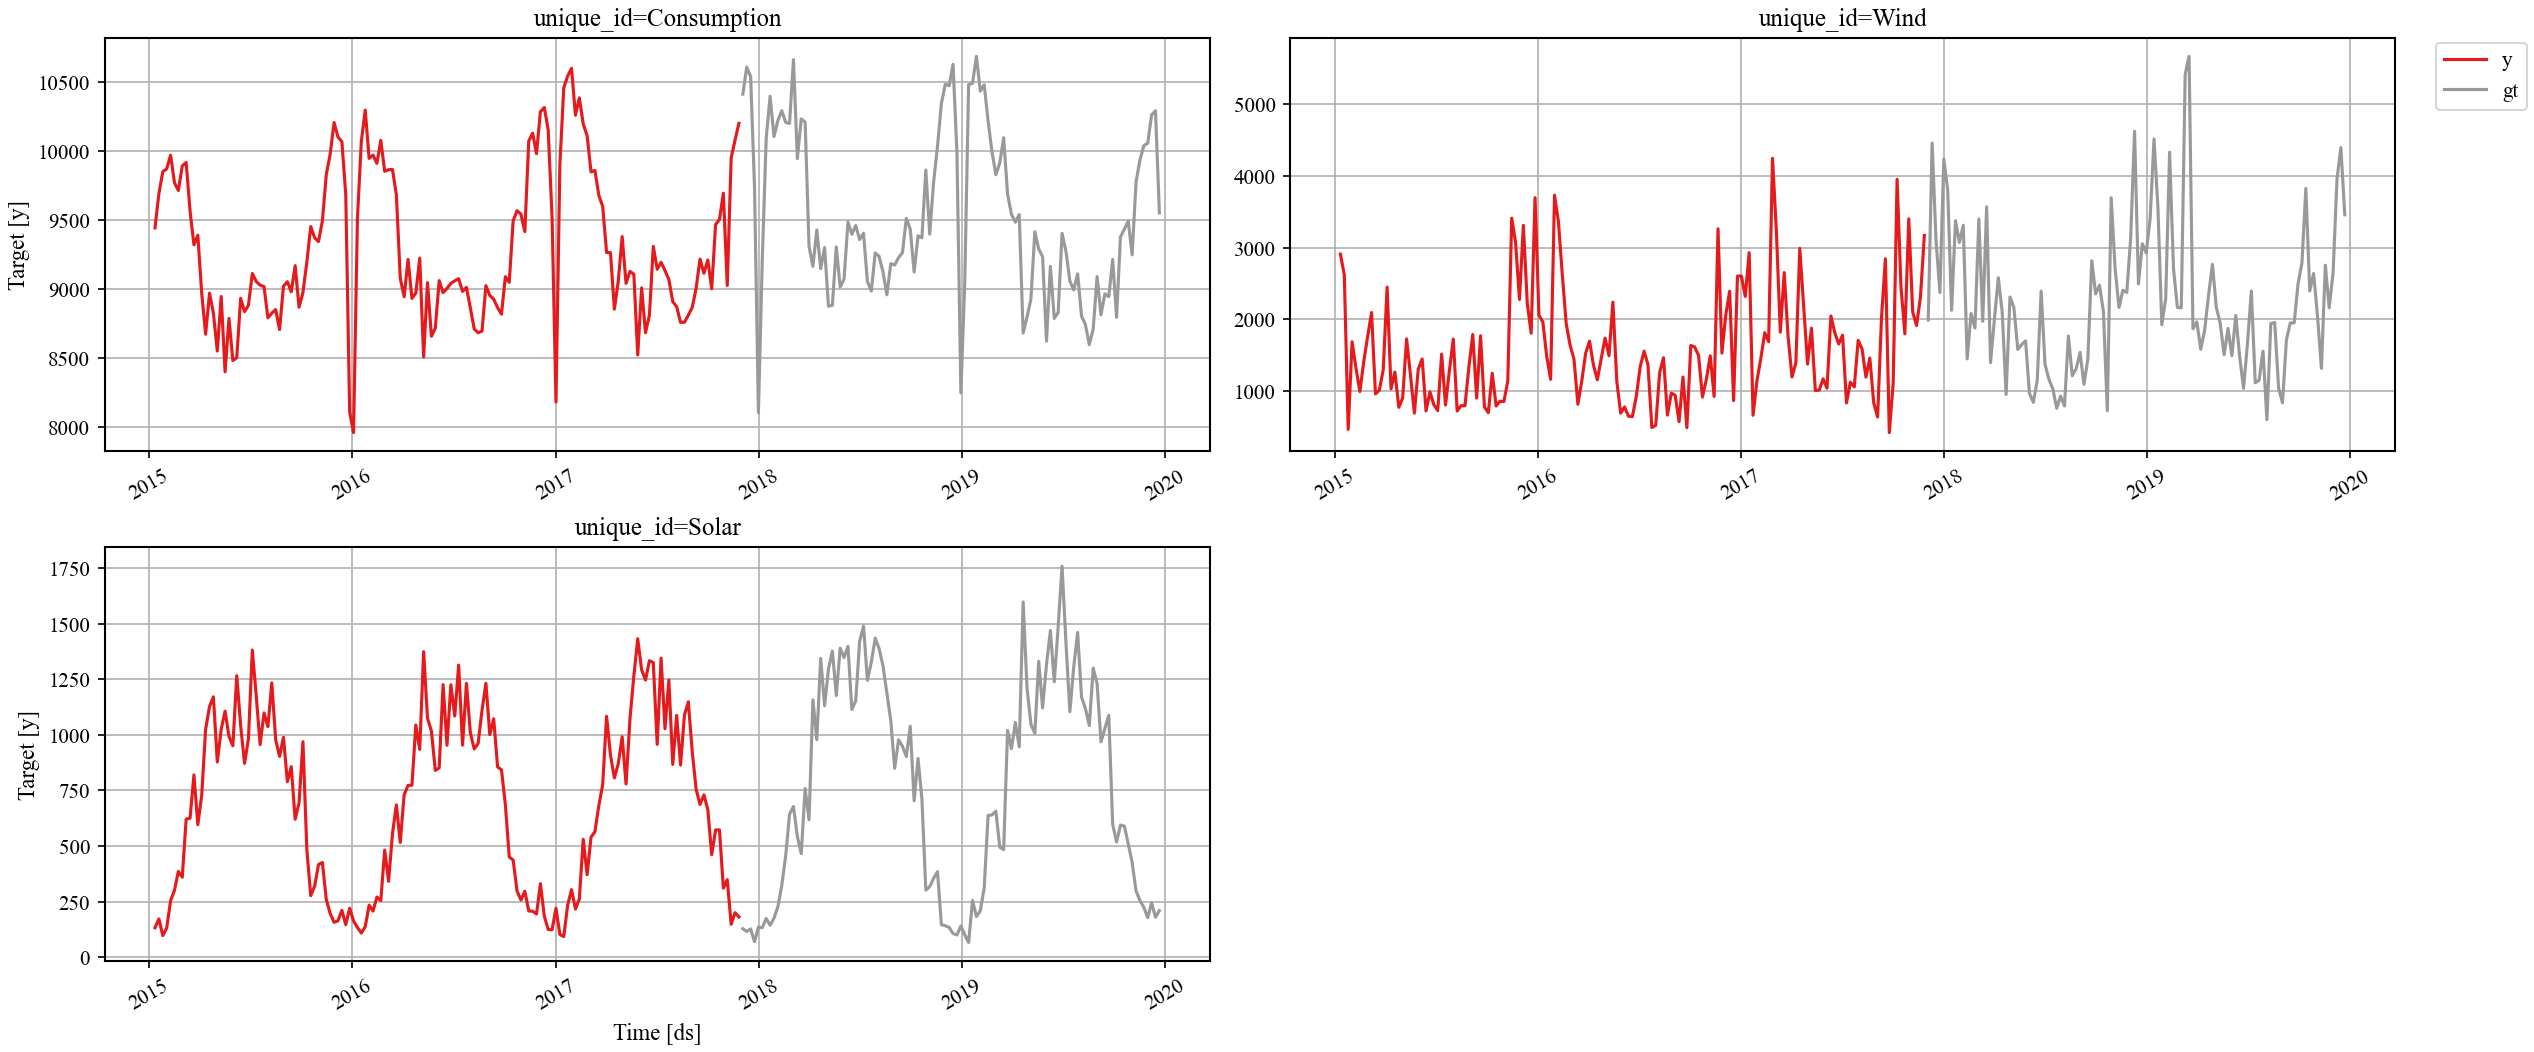

In [59]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)

df.head(1)
ts = ['Consumption','Wind',	'Solar']

exog_cols = ['temperature','radiation_direct_horizontal']

y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]

ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq

SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [60]:
# from prophet_adapter import AutoARIMAProphet
from statsforecast.models import AutoARIMA

In [61]:
import numpy as np
import pandas as pd
from typing import Optional, List
from statsforecast.models import _TS
from prophet import Prophet as FBProphet  # оригинальный prophet (fbprophet)

class TSProphet(_TS):
    """
    Prophet wrapper для StatForecast.
    ВАЖНО: В statsforecast уже есть встроенная модель Prophet — эта обёртка нужна ТОЛЬКО для кастомизации.
    """
    _tags = {
        "python_dependencies": ["prophet"],
        "capability:pred_int": True,  # поддержка prediction intervals
    }

    def __init__(
        self,
        freq: str = 'H',
        growth: str = 'linear',
        yearly_seasonality: bool = True,
        weekly_seasonality: bool = True,
        daily_seasonality: bool = True,
        seasonality_mode: str = 'additive',
        seasonality_prior_scale: float = 10.0,
        holidays: Optional[str] = None,
        country_holidays: Optional[str] = None,
        interval_width: float = 0.8,  # Добавлено
        level: Optional[List[int]] = None,
        **kwargs
    ):
        self.freq = freq
        self.growth = growth
        self.yearly_seasonality = yearly_seasonality
        self.weekly_seasonality = weekly_seasonality
        self.daily_seasonality = daily_seasonality
        self.seasonality_mode = seasonality_mode
        self.seasonality_prior_scale = seasonality_prior_scale
        self.holidays = holidays
        self.country_holidays = country_holidays
        self.interval_width = interval_width  # Добавлено
        self.kwargs = kwargs
        self.level = level
        
        if self.level:
            self.interval_width = self.level[0] / 100.0 if self.level else interval_width
        
        super().__init__()
        
        self.alias = "Prophet"

    def _create_model(self):
        """Создание модели Prophet с текущими параметрами."""
        model = FBProphet(
            growth=self.growth,
            yearly_seasonality=self.yearly_seasonality,
            weekly_seasonality=self.weekly_seasonality,
            daily_seasonality=self.daily_seasonality,
            seasonality_mode=self.seasonality_mode,
            seasonality_prior_scale=self.seasonality_prior_scale,
            interval_width=self.interval_width,  # Добавлено
            **self.kwargs
        )
        
        if self.country_holidays:
            model.add_country_holidays(country_name=self.country_holidays)
        
        return model
    
    def fit(
        self,
        y: np.ndarray,
        X: Optional[np.ndarray] = None,
    ):
        """
        Обучение на одном временном ряду.
        """
        # Получаем даты из внутреннего контекста StatForecast
        if hasattr(self, '_dates') and self._dates is not None:
            ds = self._dates
        else:
            # Если даты недоступны, используем произвольные даты
            ds = pd.date_range(start='1970-01-01', periods=len(y), freq=self.freq)
        
        # Создаём DataFrame для Prophet
        df = pd.DataFrame({'ds': ds, 'y': y})
        
        # Обучаем модель
        self.model_ = self._create_model()
        self.model_.fit(df)
        
        return self
    
    def predict(
        self,
        h: int,
        X: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
    ) -> dict:
        """
        Прогнозирование на горизонт h.
        """
        if not hasattr(self, 'model_'):
            raise RuntimeError("Модель не обучена. Вызовите .fit() перед .predict()")
        
        # Генерация будущих дат
        future = self.model_.make_future_dataframe(periods=h, freq=self.freq, include_history=False)
        
        # Прогноз
        fcst = self.model_.predict(future)
        
        # Формирование результата
        if level is not None:
            res = {
                'mean': fcst['yhat'].values,
                f'lo-{level[0]}': fcst['yhat_lower'].values,
                f'hi-{level[0]}': fcst['yhat_upper'].values
            }
        else:
            # Если level не задан, возвращаем только mean
            res = {'mean': fcst['yhat'].values}
        
        return res

    def predict_in_sample(
        self,
        level: Optional[List[int]] = None,
    ) -> dict:
        """
        In-sample прогнозы (на обучающих данных).
        """
        if not hasattr(self, 'model_'):
            raise RuntimeError("Модель не обучена")
        
        # Получаем прогноз на обучающий период
        history = self.model_.history
        fcst = self.model_.predict(history)
        
        # Всегда возвращаем одинаковое количество колонок для совместимости
        if self.level:
            primary_level = self.level[0]
            res = {
                'fitted': fcst['yhat'].values,
                f'lo-{primary_level}': fcst['yhat_lower'].values,
                f'hi-{primary_level}': fcst['yhat_upper'].values
            }
        else:
            # Возвращаем только fitted, но в формате с 3 колонками для совместимости
            res = {
                'fitted': fcst['yhat'].values,
                'lo-80': fcst['yhat_lower'].values,
                'hi-80': fcst['yhat_upper'].values
            }
        
        return res

    def forecast(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        """
        Обучение и прогнозирование.
        """
        self.fit(y, X)
        pred = self.predict(h=h, X=X_future, level=level)
        if fitted:
            pred['fitted'] = self.predict_in_sample(level=level)['fitted']
        return pred
    
    def forward(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        """
        Прогнозирование на новых данных без повторного обучения.
        """
        pred = self.predict(h=h, X=X_future, level=level)
        if fitted:
            pred['fitted'] = self.predict_in_sample(level=level)['fitted']
        return pred

In [62]:
# import numpy as np
# import pandas as pd
# from typing import Optional, List, Dict
# from statsforecast.models import _TS
# from prophet import Prophet as FBProphet


import numpy as np
import pandas as pd
from typing import Optional, List
from statsforecast.models import _TS
from prophet import Prophet as FBProphet
from prophet.make_holidays import make_holidays_df


class TSProphet(_TS):
    _tags = {
        "python_dependencies": ["prophet"],
        "capability:pred_int": True,
    }

    def __init__(
        self,
        freq: str = "H",
        growth: str = "linear",
        yearly_seasonality: bool = True,
        weekly_seasonality: bool = True,
        daily_seasonality: bool = True,
        hourly_seasonality: bool = True,   # ← НОВОЕ
        hourly_fourier: int = 8,            # ← НОВОЕ
        seasonality_mode: str = "additive",
        seasonality_prior_scale: float = 10.0,
        holidays: Optional[pd.DataFrame] = None,
        country_holidays: Optional[str] = None,
        alias: str = "Prophet",
        **kwargs,
    ):
        super().__init__()
    
        # ПЕРЕХВАТ
        if "add_country_holidays" in kwargs:
            country_holidays = kwargs.pop("add_country_holidays")
    
        self.freq = freq
        self.growth = growth
        self.yearly_seasonality = yearly_seasonality
        self.weekly_seasonality = weekly_seasonality
        self.daily_seasonality = daily_seasonality
        self.seasonality_mode = seasonality_mode
        self.seasonality_prior_scale = seasonality_prior_scale
        self.holidays = holidays
        self.country_holidays = country_holidays
        self.kwargs = kwargs
        self.alias = alias
        self.hourly_seasonality = hourly_seasonality
        self.hourly_fourier = hourly_fourier

    # --------------------------------------------------
    def _get_interval_width(self, level: Optional[List[int]]) -> float:
        return max(level) / 100.0 if level else 0.8

    def _merge_holidays(self, years):
        dfs = []

        if self.country_holidays:
            dfs.append(
                make_holidays_df(
                    year_list=years,
                    country=self.country_holidays,
                )
            )

        if self.holidays is not None:
            dfs.append(self.holidays.copy())

        if not dfs:
            return None

        return pd.concat(dfs, ignore_index=True)

    def _create_model(self, interval_width: float, years=None):
        holidays_df = self._merge_holidays(years)

        model = FBProphet(
            growth=self.growth,
            yearly_seasonality=self.yearly_seasonality,
            weekly_seasonality=self.weekly_seasonality,
            daily_seasonality=self.daily_seasonality,
            seasonality_mode=self.seasonality_mode,
            seasonality_prior_scale=self.seasonality_prior_scale,
            interval_width=interval_width,
            holidays=holidays_df,
            **self.kwargs,
        )

        return model

    # --------------------------------------------------
    def fit(self, y: np.ndarray, X=None, level=None):
        ds = self._dates if hasattr(self, "_dates") else pd.date_range(
            "1970-01-01", periods=len(y), freq=self.freq
        )

        years = sorted(set(pd.to_datetime(ds).year))
        interval_width = self._get_interval_width(level)

        df = pd.DataFrame({"ds": ds, "y": y})

        self.model_ = self._create_model(interval_width, years)
        self.model_.fit(df)

        return self

    def predict(self, h: int, X=None, level=None):
        future = self.model_.make_future_dataframe(
            periods=h, freq=self.freq, include_history=False
        )

        fcst = self.model_.predict(future)

        res = {"mean": fcst["yhat"].to_numpy()}

        if level:
            for lv in level:
                res[f"lo-{lv}"] = fcst["yhat_lower"].to_numpy()
                res[f"hi-{lv}"] = fcst["yhat_upper"].to_numpy()

        return res

    def predict_in_sample(
        self,
        level: Optional[List[int]] = None,
    ):
        if not hasattr(self, "model_"):
            raise RuntimeError("Model is not fitted")
    
        fcst = self.model_.predict(self.model_.history)
    
        values = []
        cols = []
    
        # fitted — ОБЯЗАТЕЛЬНО первым
        values.append(fcst["yhat"].to_numpy())
        cols.append("fitted")
    
        if level:
            for lv in level:
                values.append(fcst["yhat_lower"].to_numpy())
                values.append(fcst["yhat_upper"].to_numpy())
                cols.extend([f"lo-{lv}", f"hi-{lv}"])
    
        values = np.column_stack(values)
    
        return {
            "values": values,
            "cols": cols,
        }

    def forecast(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        self.fit(y=y, X=X, level=level)
    
        out = self.predict(h=h, X=X_future, level=level)
    
        if fitted:
            ins = self.model_.predict(self.model_.history)
    
            out["fitted"] = ins["yhat"].to_numpy()
    
            if level:
                for lv in level:
                    out[f"fitted-lo-{lv}"] = ins["yhat_lower"].to_numpy()
                    out[f"fitted-hi-{lv}"] = ins["yhat_upper"].to_numpy()
    
        return out


    def forward(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        out = self.predict(h=h, X=X_future, level=level)
    
        if fitted:
            ins = self.model_.predict(self.model_.history)
            out["fitted"] = ins["yhat"].to_numpy()
    
            if level:
                for lv in level:
                    out[f"fitted-lo-{lv}"] = ins["yhat_lower"].to_numpy()
                    out[f"fitted-hi-{lv}"] = ins["yhat_upper"].to_numpy()
    
        return out

### AS RESULT

In [63]:
import numpy as np
import pandas as pd
from typing import Optional, List, Dict
from statsforecast.models import _TS
from prophet import Prophet as FBProphet
from prophet.make_holidays import make_holidays_df

class TSProphet(_TS):
    """
    Кастомный Prophet wrapper для StatsForecast с поддержкой:
    - кастомных сезонностей (hourly/daily/weekly/yearly)
    - prediction intervals (level)
    - country holidays и пользовательских праздников
    """

    _tags = {
        "python_dependencies": ["prophet"],
        "capability:pred_int": True,
    }

    def __init__(
        self,
        freq: str = "H",
        growth: str = "linear",
        yearly_seasonality: bool = True,
        weekly_seasonality: bool = True,
        daily_seasonality: bool = True,
        custom_seasonalities: Optional[List[Dict]] = None,
        seasonality_mode: str = "additive",
        seasonality_prior_scale: float = 10.0,
        holidays: Optional[pd.DataFrame] = None,
        country_holidays: Optional[str] = None,
        alias: str = "Prophet",
        **kwargs,
    ):
        super().__init__()

        # Перехват устаревших аргументов
        if "add_country_holidays" in kwargs:
            country_holidays = kwargs.pop("add_country_holidays")

        self.freq = freq
        self.growth = growth
        self.yearly_seasonality = yearly_seasonality
        self.weekly_seasonality = weekly_seasonality
        self.daily_seasonality = daily_seasonality
        self.custom_seasonalities = custom_seasonalities or []
        self.seasonality_mode = seasonality_mode
        self.seasonality_prior_scale = seasonality_prior_scale
        self.holidays = holidays
        self.country_holidays = country_holidays
        self.kwargs = kwargs
        self.alias = alias

    # --------------------------------------------------
    def _get_interval_width(self, level: Optional[List[int]]) -> float:
        return max(level) / 100.0 if level else 0.8

    def _merge_holidays(self, years):
        dfs = []
        if self.country_holidays:
            dfs.append(make_holidays_df(year_list=years, country=self.country_holidays))
        if self.holidays is not None:
            dfs.append(self.holidays.copy())
        if not dfs:
            return None
        return pd.concat(dfs, ignore_index=True)

    # --------------------------------------------------
    def _add_custom_seasonalities(self, model: FBProphet):
        for s in self.custom_seasonalities:
            model.add_seasonality(
                name=s["name"],
                period=s["period"],
                fourier_order=s.get("fourier_order", 5),
            )

    def _create_model(self, interval_width: float, years=None):
        holidays_df = self._merge_holidays(years)

        model = FBProphet(
            growth=self.growth,
            yearly_seasonality=self.yearly_seasonality,
            weekly_seasonality=self.weekly_seasonality,
            daily_seasonality=self.daily_seasonality,
            seasonality_mode=self.seasonality_mode,
            seasonality_prior_scale=self.seasonality_prior_scale,
            interval_width=interval_width,
            holidays=holidays_df,
            **self.kwargs,
        )

        self._add_custom_seasonalities(model)
        return model

    # --------------------------------------------------
    def fit(self, y: np.ndarray, X=None, level=None):
        ds = self._dates if hasattr(self, "_dates") else pd.date_range(
            "1970-01-01", periods=len(y), freq=self.freq
        )
        years = sorted(set(pd.to_datetime(ds).year))
        interval_width = self._get_interval_width(level)

        df = pd.DataFrame({"ds": ds, "y": y})
        self.model_ = self._create_model(interval_width, years)
        self.model_.fit(df)
        return self

    def predict(self, h: int, X=None, level=None):
        future = self.model_.make_future_dataframe(periods=h, freq=self.freq, include_history=False)
        fcst = self.model_.predict(future)

        res = {"mean": fcst["yhat"].to_numpy()}
        if level:
            for lv in level:
                res[f"lo-{lv}"] = fcst["yhat_lower"].to_numpy()
                res[f"hi-{lv}"] = fcst["yhat_upper"].to_numpy()
        return res

    def predict_in_sample(self, level: Optional[List[int]] = None):
        fcst = self.model_.predict(self.model_.history)
        values = [fcst["yhat"].to_numpy()]
        cols = ["fitted"]
        if level:
            for lv in level:
                values.extend([fcst["yhat_lower"].to_numpy(), fcst["yhat_upper"].to_numpy()])
                cols.extend([f"lo-{lv}", f"hi-{lv}"])
        values = np.column_stack(values)
        return {"values": values, "cols": cols}

    # --------------------------------------------------
    def forecast(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        self.fit(y=y, X=X, level=level)
        out = self.predict(h=h, X=X_future, level=level)

        if fitted:
            ins = self.model_.predict(self.model_.history)
            out["fitted"] = ins["yhat"].to_numpy()
            if level:
                for lv in level:
                    out[f"fitted-lo-{lv}"] = ins["yhat_lower"].to_numpy()
                    out[f"fitted-hi-{lv}"] = ins["yhat_upper"].to_numpy()
        return out

    def forward(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        out = self.predict(h=h, X=X_future, level=level)
        if fitted:
            ins = self.model_.predict(self.model_.history)
            out["fitted"] = ins["yhat"].to_numpy()
            if level:
                for lv in level:
                    out[f"fitted-lo-{lv}"] = ins["yhat_lower"].to_numpy()
                    out[f"fitted-hi-{lv}"] = ins["yhat_upper"].to_numpy()
        return out


In [64]:
from statsforecast import StatsForecast
LEVELS = [70,90]

models = [TSProphet(freq=FREQ, yearly_seasonality=True, alias='test_1' ),
          TSProphet(freq=FREQ, 
                   seasonality_mode='additive',
                         n_changepoints=int(len(df_train) / 4),
                         add_country_holidays="RU",
                         yearly_seasonality=True)]

sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

13:12:31 - cmdstanpy - INFO - Chain [1] start processing
13:12:31 - cmdstanpy - INFO - Chain [1] done processing
13:12:31 - cmdstanpy - INFO - Chain [1] start processing
13:12:32 - cmdstanpy - INFO - Chain [1] done processing
13:12:32 - cmdstanpy - INFO - Chain [1] start processing
13:12:32 - cmdstanpy - INFO - Chain [1] done processing
13:12:32 - cmdstanpy - INFO - Chain [1] start processing
13:12:32 - cmdstanpy - INFO - Chain [1] done processing
13:12:32 - cmdstanpy - INFO - Chain [1] start processing
13:12:32 - cmdstanpy - INFO - Chain [1] done processing
13:12:32 - cmdstanpy - INFO - Chain [1] start processing
13:12:32 - cmdstanpy - INFO - Chain [1] done processing


In [65]:
in_sample

,unique_id,ds,y,test_1,test_1-lo-70,test_1-hi-70,test_1-lo-90,test_1-hi-90,Prophet,Prophet-lo-70,Prophet-hi-70,Prophet-lo-90,Prophet-hi-90
0,Consumption,2015-01-11,9440.105,9253.918597,8933.006915,9607.555397,8933.006915,9607.555397,9246.533152,8893.424722,9589.408723,8893.424722,9589.408723
1,Consumption,2015-01-18,9689.010,9891.430169,9542.076255,10228.765672,9542.076255,10228.765672,9885.385364,9538.096088,10232.370775,9538.096088,10232.370775
2,Consumption,2015-01-25,9847.035,10184.005318,9861.399166,10508.731272,9861.399166,10508.731272,10178.543559,9838.720084,10518.953701,9838.720084,10518.953701
3,Consumption,2015-02-01,9867.317,10086.246086,9736.738547,10448.001739,9736.738547,10448.001739,10080.907183,9723.882727,10405.976869,9723.882727,10405.976869
4,Consumption,2015-02-08,9966.415,9857.824425,9513.393468,10205.893790,9513.393468,10205.893790,9852.649821,9513.431362,10200.481291,9513.431362,10200.481291
...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,Wind,2017-10-29,3400.181,1622.730793,536.705476,2737.166439,536.705476,2737.166439,1619.218384,554.758210,2556.575387,554.758210,2556.575387
449,Wind,2017-11-05,2105.870,1742.494719,679.850556,2755.578547,679.850556,2755.578547,1734.758494,705.702705,2742.485844,705.702705,2742.485844
450,Wind,2017-11-12,1914.513,2248.389367,1148.480769,3267.013155,1148.480769,3267.013155,2232.128363,1182.706688,3328.363587,1182.706688,3328.363587
451,Wind,2017-11-19,2309.436,2797.581051,1720.364465,3846.390962,1720.364465,3846.390962,2776.886982,1726.991947,3867.733359,1726.991947,3867.733359


In [66]:
fcst_sf

,unique_id,ds,test_1,test_1-lo-70,test_1-hi-70,test_1-lo-90,test_1-hi-90,Prophet,Prophet-lo-70,Prophet-hi-70,Prophet-lo-90,Prophet-hi-90
0,Consumption,2017-12-03,10492.007309,10159.979353,10840.054006,10159.979353,10840.054006,10490.751009,10142.070679,10859.903387,10142.070679,10859.903387
1,Consumption,2017-12-10,10292.650702,9929.775638,10639.676147,9929.775638,10639.676147,10291.110062,9954.603877,10647.394320,9954.603877,10647.394320
2,Consumption,2017-12-17,9679.310599,9307.632786,10006.388770,9307.632786,10006.388770,9677.361776,9328.389084,10014.238860,9328.389084,10014.238860
3,Consumption,2017-12-24,9024.742835,8669.522104,9383.724652,8669.522104,9383.724652,9022.829199,8651.274609,9367.072481,8651.274609,9367.072481
4,Consumption,2017-12-31,8796.851975,8457.084770,9132.886038,8457.084770,9132.886038,8795.813768,8452.200942,9142.271146,8452.200942,9142.271146
...,...,...,...,...,...,...,...,...,...,...,...,...
319,Wind,2019-11-24,3382.086606,2278.232089,4441.716753,2278.232089,4441.716753,3375.522091,2399.069670,4430.994466,2399.069670,4430.994466
320,Wind,2019-12-01,3255.678647,2157.995889,4285.407138,2157.995889,4285.407138,3261.088904,2252.887069,4310.403530,2252.887069,4310.403530
321,Wind,2019-12-08,2900.647317,1797.847134,4069.881701,1797.847134,4069.881701,2919.533614,1877.876937,4031.749534,1877.876937,4031.749534
322,Wind,2019-12-15,2748.449133,1650.694660,3771.880208,1650.694660,3771.880208,2773.021579,1707.963411,3813.072318,1707.963411,3813.072318


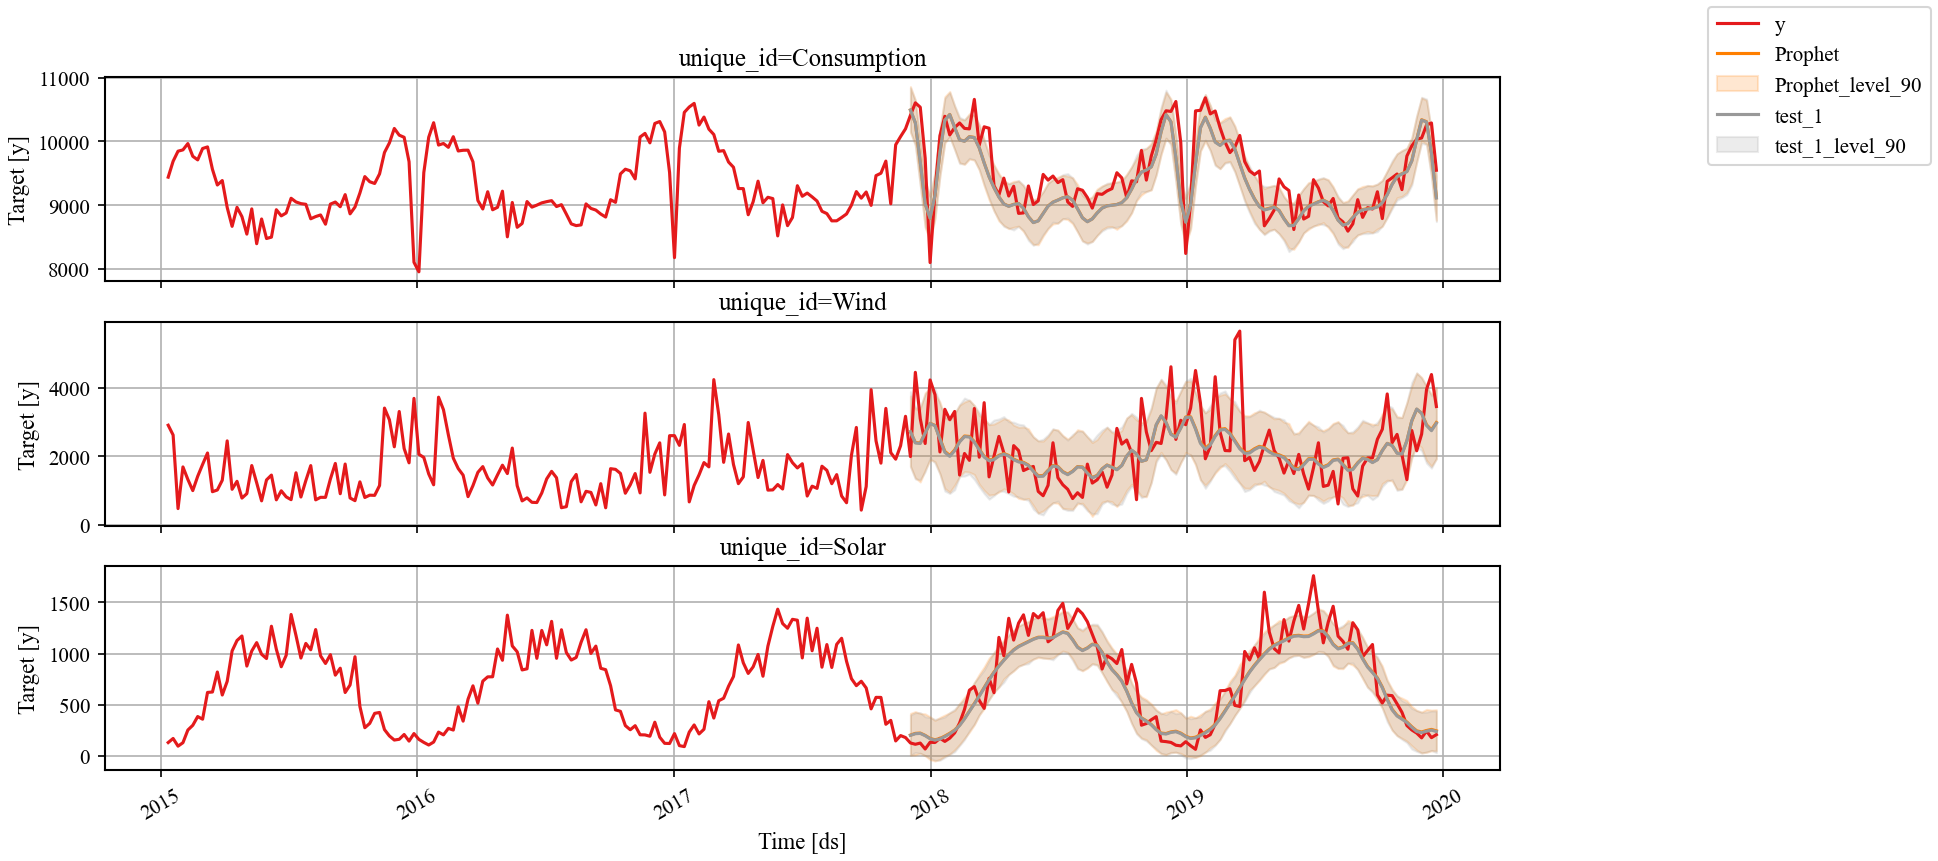

In [74]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, coverage ], levels=LEVELS[1:])

### CV

In [68]:
cv_df = sf.cross_validation(
    df=panel_df,
    h=FH//2,
    n_windows=4,
    step_size=FH//2, 
    # refit=True,
)
cv_df.head()

13:12:32 - cmdstanpy - INFO - Chain [1] start processing
13:12:33 - cmdstanpy - INFO - Chain [1] done processing
13:12:33 - cmdstanpy - INFO - Chain [1] start processing
13:12:33 - cmdstanpy - INFO - Chain [1] done processing
13:12:33 - cmdstanpy - INFO - Chain [1] start processing
13:12:33 - cmdstanpy - INFO - Chain [1] done processing
13:12:33 - cmdstanpy - INFO - Chain [1] start processing
13:12:33 - cmdstanpy - INFO - Chain [1] done processing
13:12:33 - cmdstanpy - INFO - Chain [1] start processing
13:12:34 - cmdstanpy - INFO - Chain [1] done processing
13:12:34 - cmdstanpy - INFO - Chain [1] start processing
13:12:34 - cmdstanpy - INFO - Chain [1] done processing
13:12:34 - cmdstanpy - INFO - Chain [1] start processing
13:12:34 - cmdstanpy - INFO - Chain [1] done processing
13:12:34 - cmdstanpy - INFO - Chain [1] start processing
13:12:34 - cmdstanpy - INFO - Chain [1] done processing
13:12:34 - cmdstanpy - INFO - Chain [1] start processing
13:12:34 - cmdstanpy - INFO - Chain [1]

,unique_id,ds,cutoff,y,test_1,Prophet
0,Consumption,2015-11-08,2015-11-01,9491.391,9944.701083,9944.923535
1,Consumption,2015-11-15,2015-11-01,9826.524,12341.762436,12342.311465
2,Consumption,2015-11-22,2015-11-01,9976.205,17179.874405,17180.886312
3,Consumption,2015-11-29,2015-11-01,10203.088,24010.325684,24011.763932
4,Consumption,2015-12-06,2015-11-01,10097.922,31310.819069,31312.447556


### CONFORMAL PI

In [69]:
from statsforecast.utils import ConformalIntervals

# Безопасный горизонт для конформной калибровки
h = min(FH, df_train.groupby('unique_id').size().min() // 3)

# Конформная калибровка (n_windows=2 обязательно)
pi = ConformalIntervals(h=h, n_windows=2)

forecasts = sf.forecast(
    df=df_train,
    h=h,
    level=LEVELS,           # уровень PI
    prediction_intervals=pi
)

13:12:36 - cmdstanpy - INFO - Chain [1] start processing
13:12:36 - cmdstanpy - INFO - Chain [1] done processing
13:12:36 - cmdstanpy - INFO - Chain [1] start processing
13:12:36 - cmdstanpy - INFO - Chain [1] done processing
13:12:36 - cmdstanpy - INFO - Chain [1] start processing
13:12:36 - cmdstanpy - INFO - Chain [1] done processing
13:12:37 - cmdstanpy - INFO - Chain [1] start processing
13:12:37 - cmdstanpy - INFO - Chain [1] done processing
13:12:37 - cmdstanpy - INFO - Chain [1] start processing
13:12:37 - cmdstanpy - INFO - Chain [1] done processing
13:12:37 - cmdstanpy - INFO - Chain [1] start processing
13:12:37 - cmdstanpy - INFO - Chain [1] done processing


In [70]:
forecasts

,unique_id,ds,test_1,test_1-lo-70,test_1-hi-70,test_1-lo-90,test_1-hi-90,Prophet,Prophet-lo-70,Prophet-hi-70,Prophet-lo-90,Prophet-hi-90
0,Consumption,2017-12-03,10492.007309,10150.438452,10828.197231,10150.438452,10828.197231,10490.751009,10151.928652,10856.736988,10151.928652,10856.736988
1,Consumption,2017-12-10,10292.650702,9926.954331,10660.188289,9926.954331,10660.188289,10291.110062,9933.638536,10649.238715,9933.638536,10649.238715
2,Consumption,2017-12-17,9679.310599,9292.279465,10018.491534,9292.279465,10018.491534,9677.361776,9308.960257,10022.506824,9308.960257,10022.506824
3,Consumption,2017-12-24,9024.742835,8675.483852,9371.304319,8675.483852,9371.304319,9022.829199,8652.330528,9380.182304,8652.330528,9380.182304
4,Consumption,2017-12-31,8796.851975,8462.162646,9137.134190,8462.162646,9137.134190,8795.813768,8449.573722,9143.539656,8449.573722,9143.539656
...,...,...,...,...,...,...,...,...,...,...,...,...
145,Wind,2018-10-14,2178.283991,1101.202365,3271.067503,1101.202365,3271.067503,2175.645368,1138.835592,3160.370416,1138.835592,3160.370416
146,Wind,2018-10-21,2067.807445,973.823232,3179.910359,973.823232,3179.910359,2067.492634,1031.429398,3120.975600,1031.429398,3120.975600
147,Wind,2018-10-28,1850.804228,805.412570,2968.099893,805.412570,2968.099893,1853.042889,826.422871,2921.554366,826.422871,2921.554366
148,Wind,2018-11-04,1896.198400,759.705923,3019.188465,759.705923,3019.188465,1895.428338,820.941767,2929.659580,820.941767,2929.659580


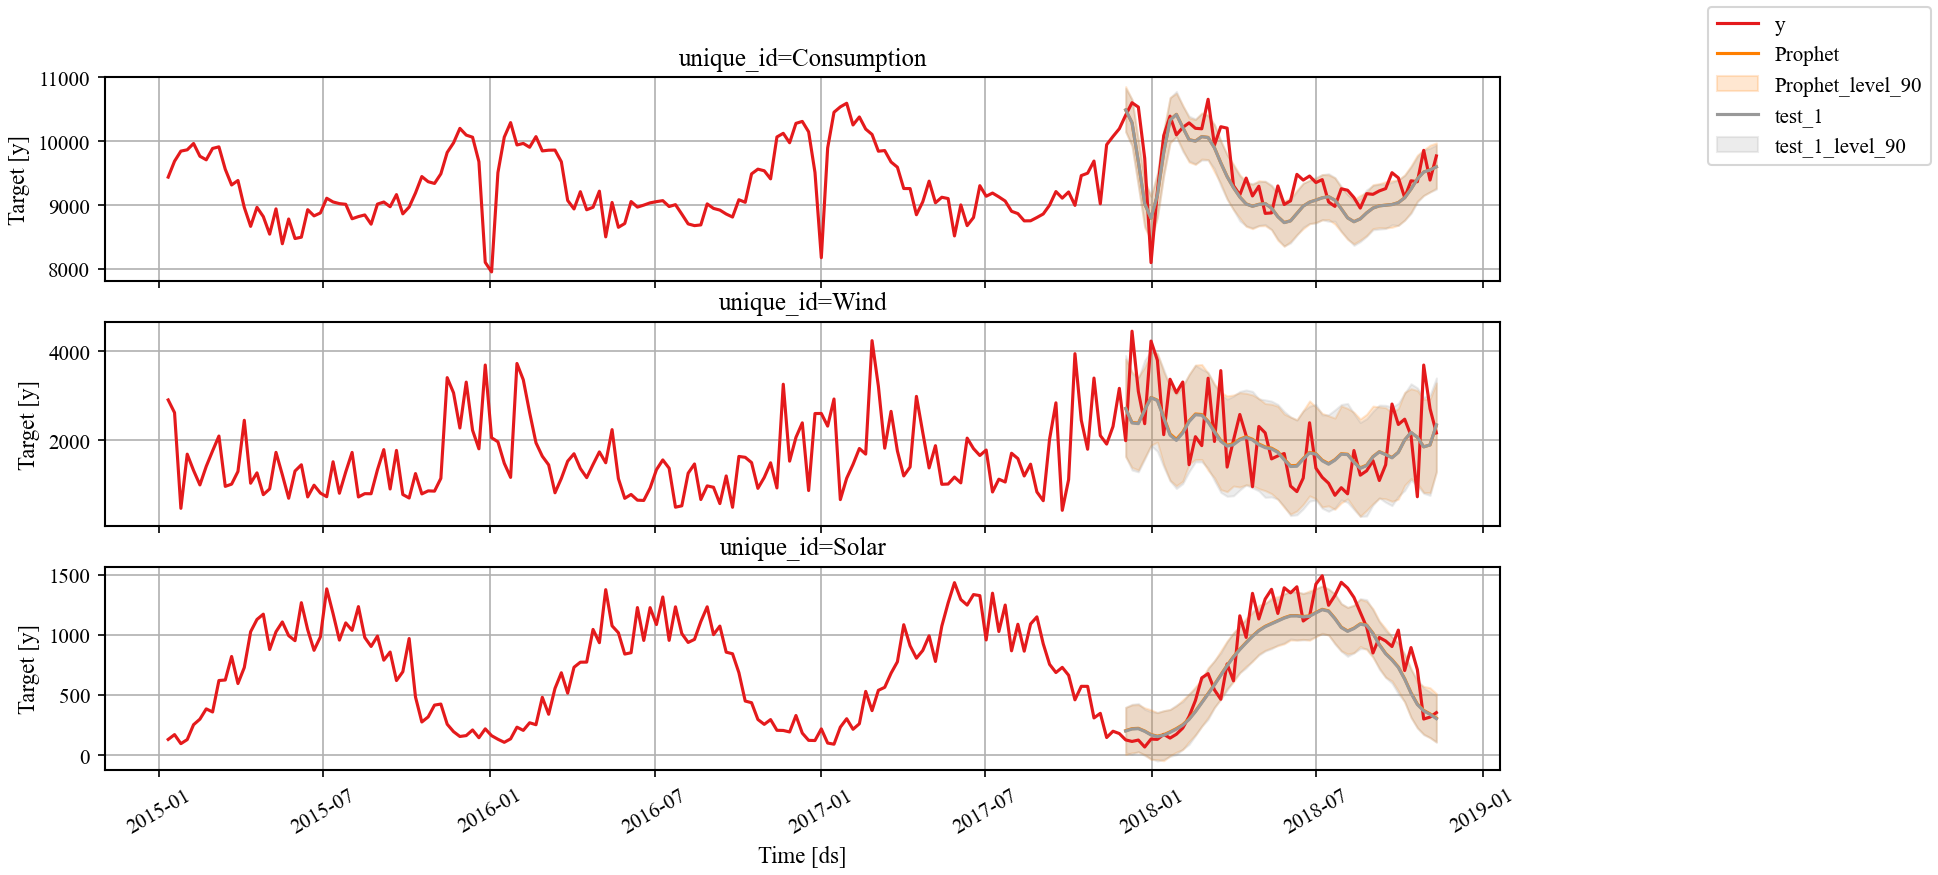

In [75]:
evaluate_and_plot(df_train, df_test, forecasts, metrics = [mae, rmse, coverage], levels=LEVELS[1:])

### EXDOG

In [30]:
ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']
exog_cols = ['temperature','radiation_direct_horizontal']
df_exog = y[exog_cols].reset_index()
df_exog['ds'] = y.index

In [31]:
for col in exog_cols:
    # Сохраняем первые SEASON значений ДО сдвига
    original_first_season = df_exog[col].iloc[:SEASON].copy()    
    # Сдвигаем ВЕСЬ столбец вниз на SEASON
    df_exog[col] = df_exog[col].shift(SEASON)    
    # Заполняем первые SEASON строк — БЕЗ предупреждения
    df_exog.loc[:SEASON - 1, col] = original_first_season.values
df_exog.head(2) 

,time,temperature,radiation_direct_horizontal,ds
0,2015-01-11,2.488536,5.554645,2015-01-11
1,2015-01-18,3.012375,7.504608,2015-01-18


In [32]:
df_exog = y[exog_cols].reset_index()
df_exog['ds'] = y.index

panel_list = [pd.DataFrame({'ds':y.index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок

panel_df = panel_df.merge(df_exog, on='ds', how='left')
panel_df = panel_df[[*base_cols, *exog_cols]]
panel_df.head(2)

,unique_id,ds,y,temperature,radiation_direct_horizontal
0,Consumption,2015-01-11,9440.105,2.488536,5.554645
1,Consumption,2015-01-18,9689.010,3.012375,7.504608


In [33]:
df_test_exdogs  = panel_df[base_cols+exog_cols].groupby("unique_id").tail(FH)
df_train_exdogs = panel_df[base_cols+exog_cols].drop(df_test.index).reset_index(drop=True)

X_test  = df_test_exdogs.drop(columns = 'y')
X_train = df_train_exdogs.drop(columns = 'y')

In [78]:
fcst_sf = sf.forecast(df=df_train_exdogs, h=FH, X_df=X_test, level = LEVELS, fitted=True, prediction_intervals=pi)
eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

# plot_series(df_train, eval_sf, max_insample_length=SEASON, palette='Set1', )

13:16:36 - cmdstanpy - INFO - Chain [1] start processing
13:16:36 - cmdstanpy - INFO - Chain [1] done processing
13:16:36 - cmdstanpy - INFO - Chain [1] start processing
13:16:36 - cmdstanpy - INFO - Chain [1] done processing
13:16:36 - cmdstanpy - INFO - Chain [1] start processing
13:16:36 - cmdstanpy - INFO - Chain [1] done processing
13:16:36 - cmdstanpy - INFO - Chain [1] start processing
13:16:36 - cmdstanpy - INFO - Chain [1] done processing
13:16:36 - cmdstanpy - INFO - Chain [1] start processing
13:16:36 - cmdstanpy - INFO - Chain [1] done processing
13:16:36 - cmdstanpy - INFO - Chain [1] start processing
13:16:36 - cmdstanpy - INFO - Chain [1] done processing


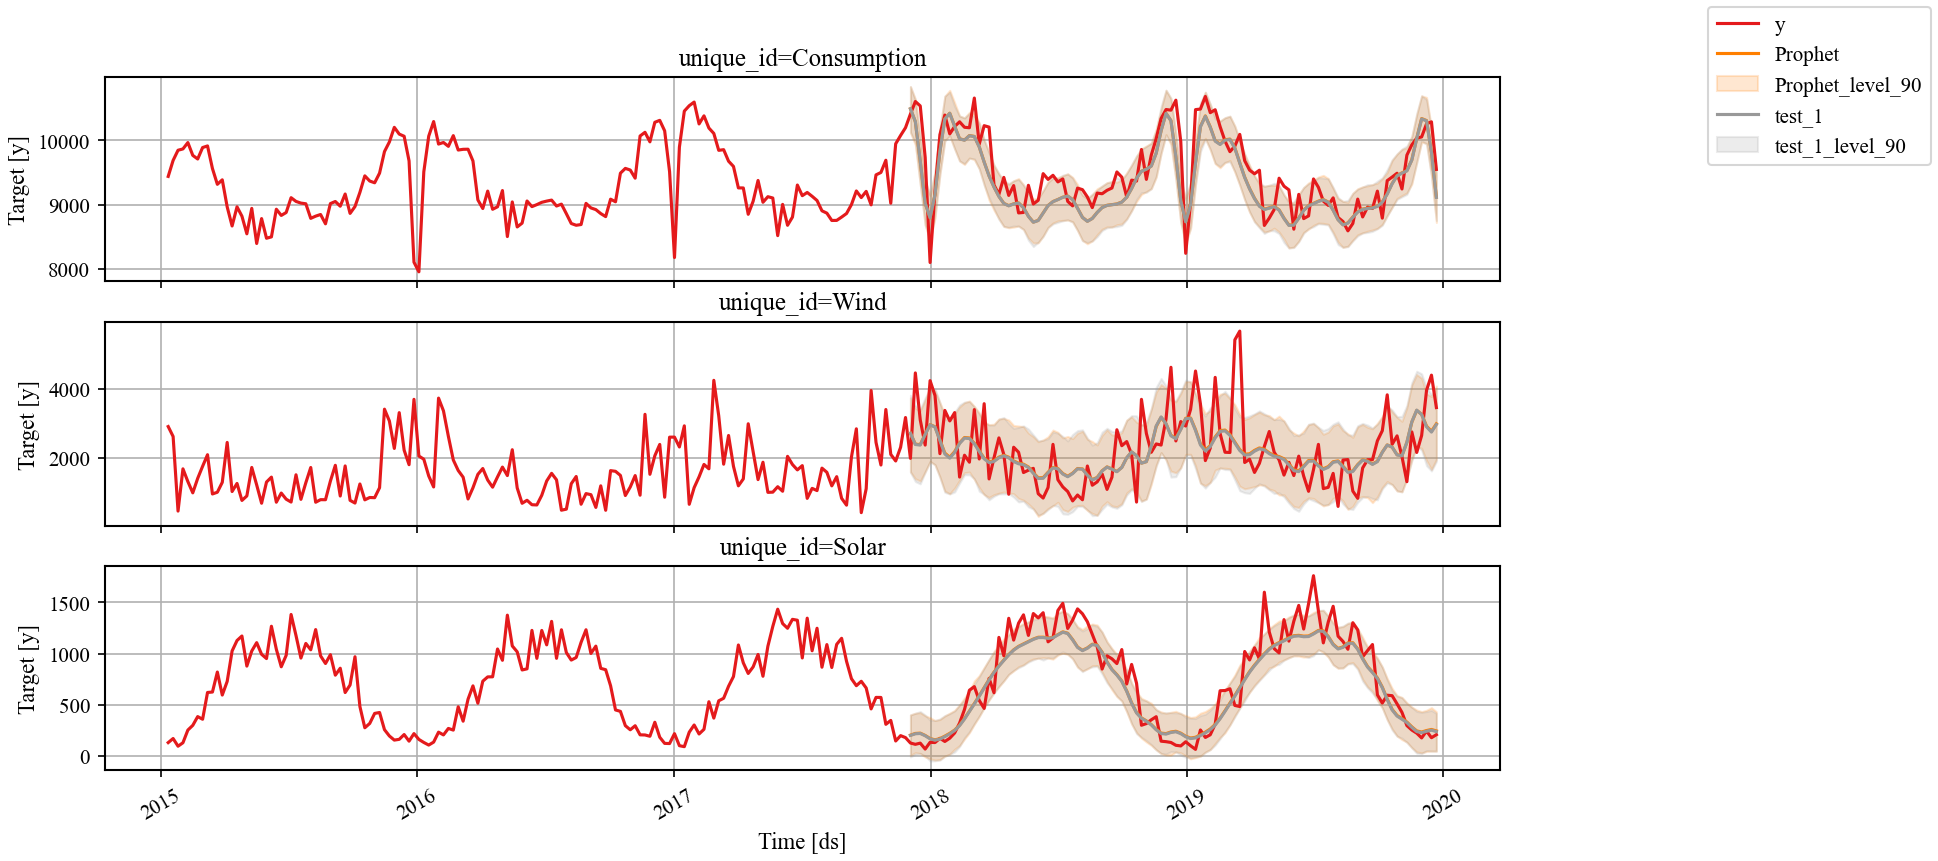

In [79]:
evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, coverage], levels=LEVELS[1:])

#### HOURLY

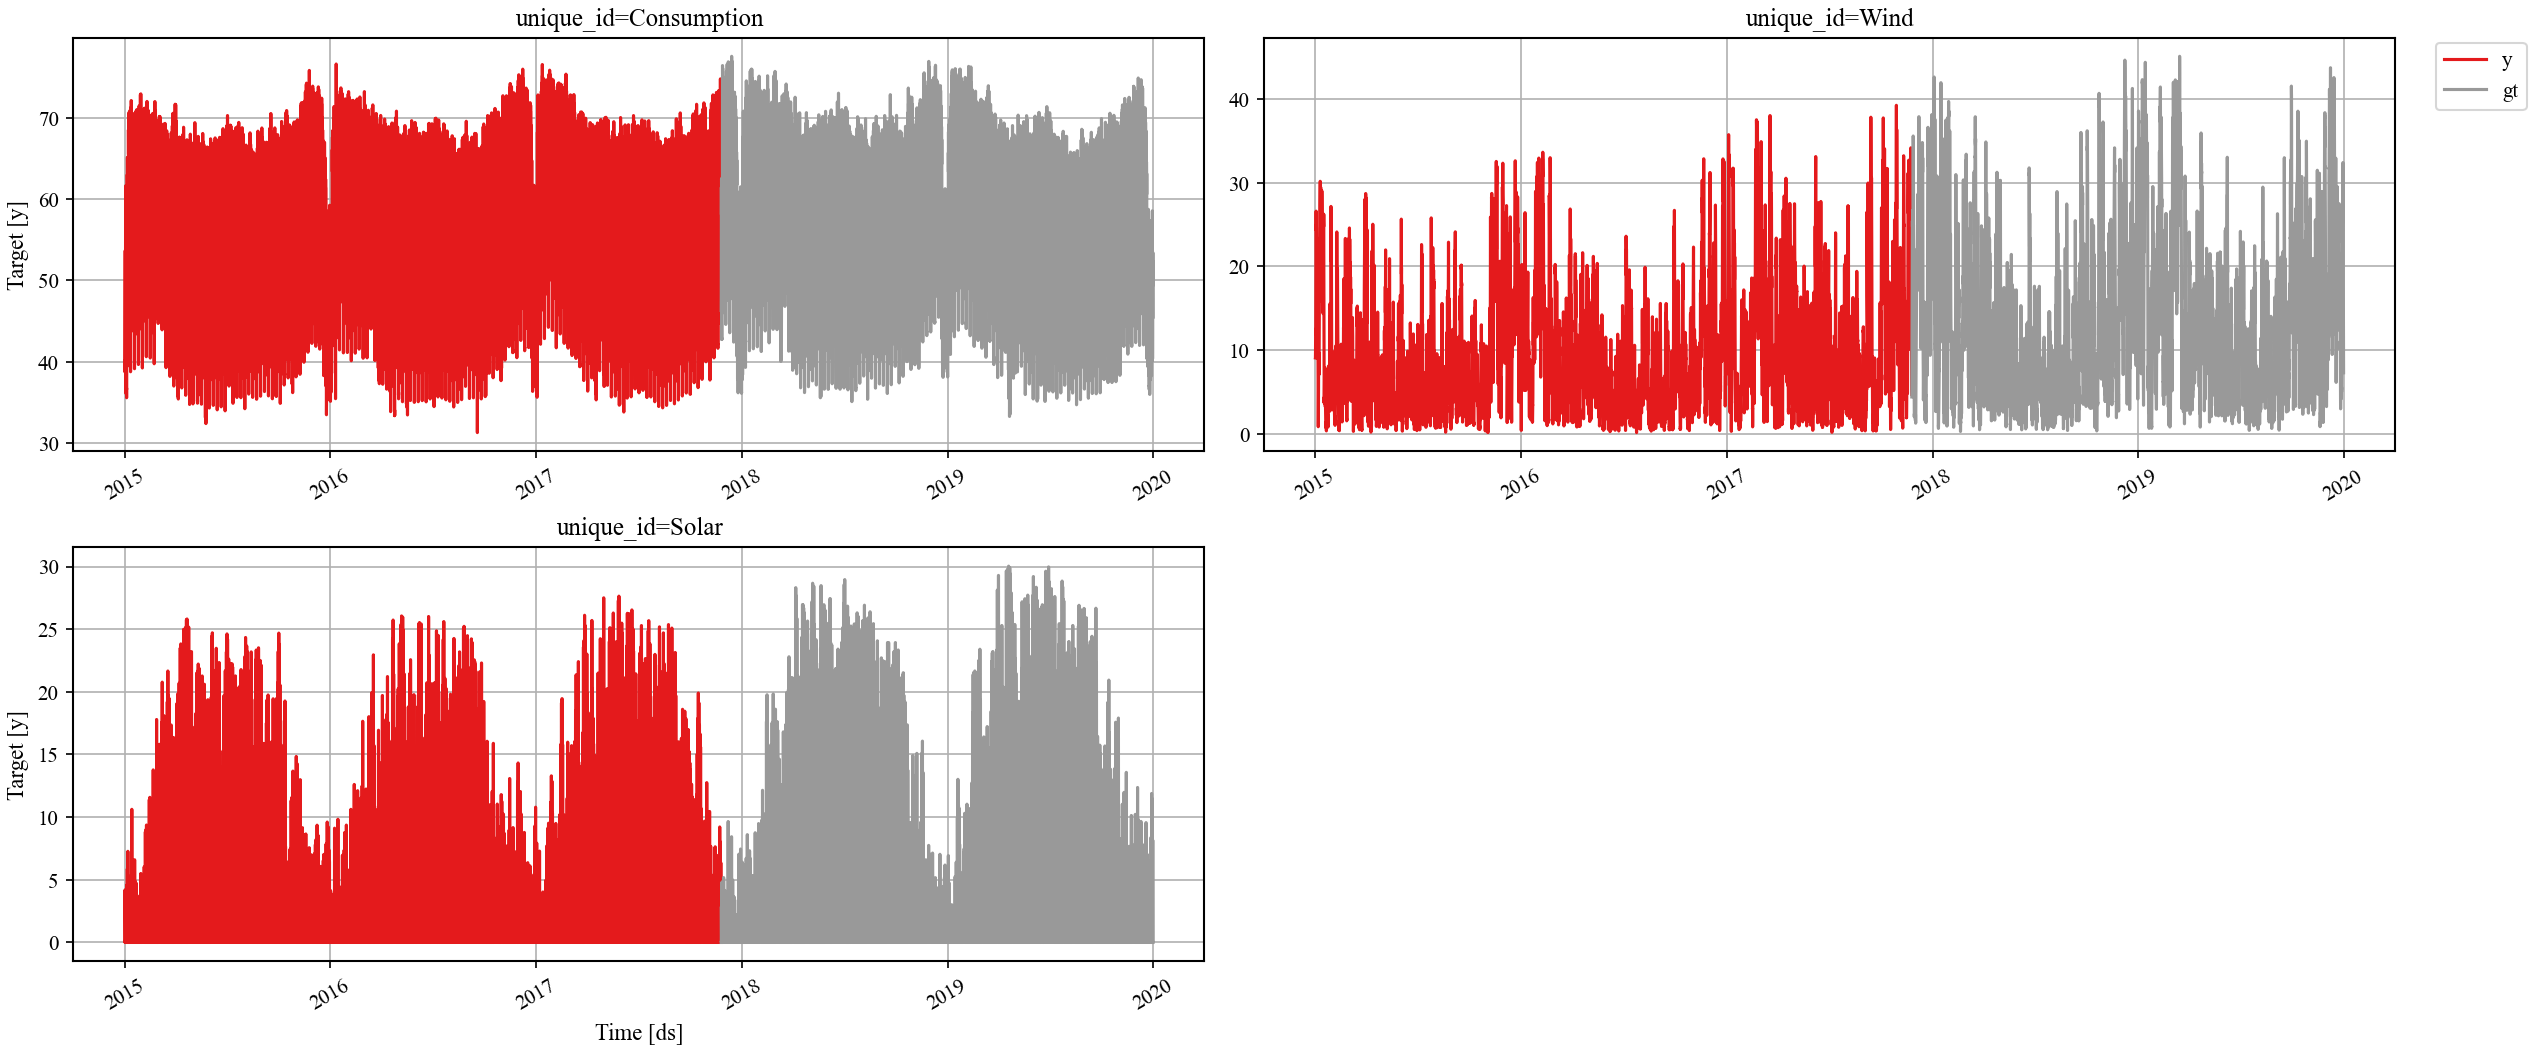

In [35]:
y = df_.resample('h').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq


SEASON = [24,24*7,int(24*365.25)] 

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [36]:
custom_seasonalities = [
    {"name": "hourly", "period": 24, "fourier_order": 8},
    {"name": "half_day", "period": 12, "fourier_order": 5},
]

models = [TSProphet(freq=FREQ,     
                    weekly_seasonality=True,
                    yearly_seasonality=True,
                    daily_seasonality=True, alias='test_1' ),
          TSProphet(freq=FREQ, 
                       seasonality_mode='additive',
                        seasonality_prior_scale=0.9,  # уменьшили — сезонность будет мягче
                        changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
                        add_country_holidays='GE',
                        weekly_seasonality=True,
                        yearly_seasonality=True,
                        daily_seasonality=True,),
        TSProphet(freq=FREQ, 
                       seasonality_mode='additive',
                        seasonality_prior_scale=0.9,  # уменьшили — сезонность будет мягче
                        changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
                        add_country_holidays='GE',
                        weekly_seasonality=True,
                        yearly_seasonality=True,
                        daily_seasonality=False,
                        custom_seasonalities=custom_seasonalities, 
                        alias='test_custom'),
         ]




sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

13:00:04 - cmdstanpy - INFO - Chain [1] start processing
13:00:08 - cmdstanpy - INFO - Chain [1] done processing
13:00:13 - cmdstanpy - INFO - Chain [1] start processing
13:00:15 - cmdstanpy - INFO - Chain [1] done processing
13:00:21 - cmdstanpy - INFO - Chain [1] start processing
13:00:23 - cmdstanpy - INFO - Chain [1] done processing
13:00:28 - cmdstanpy - INFO - Chain [1] start processing
13:00:29 - cmdstanpy - INFO - Chain [1] done processing
13:00:35 - cmdstanpy - INFO - Chain [1] start processing
13:00:36 - cmdstanpy - INFO - Chain [1] done processing
13:00:42 - cmdstanpy - INFO - Chain [1] start processing
13:00:43 - cmdstanpy - INFO - Chain [1] done processing
13:00:48 - cmdstanpy - INFO - Chain [1] start processing
13:00:50 - cmdstanpy - INFO - Chain [1] done processing
13:00:56 - cmdstanpy - INFO - Chain [1] start processing
13:00:58 - cmdstanpy - INFO - Chain [1] done processing
13:01:04 - cmdstanpy - INFO - Chain [1] start processing
13:01:05 - cmdstanpy - INFO - Chain [1]

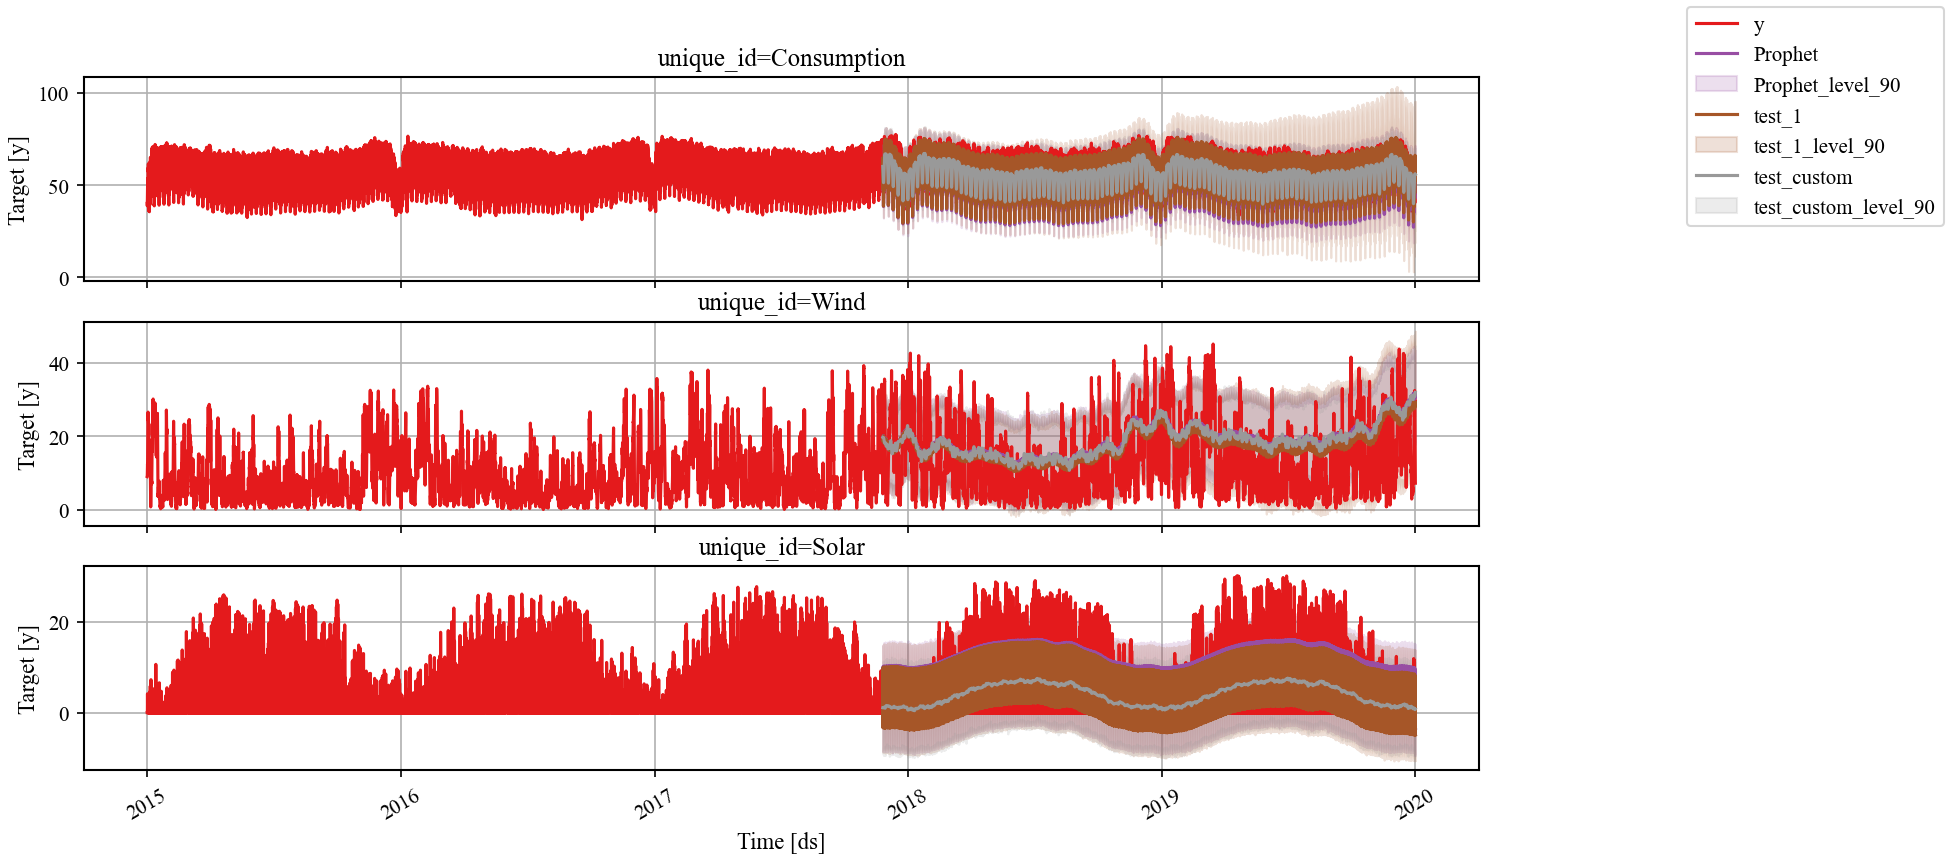

In [37]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], levels=LEVELS[1:])

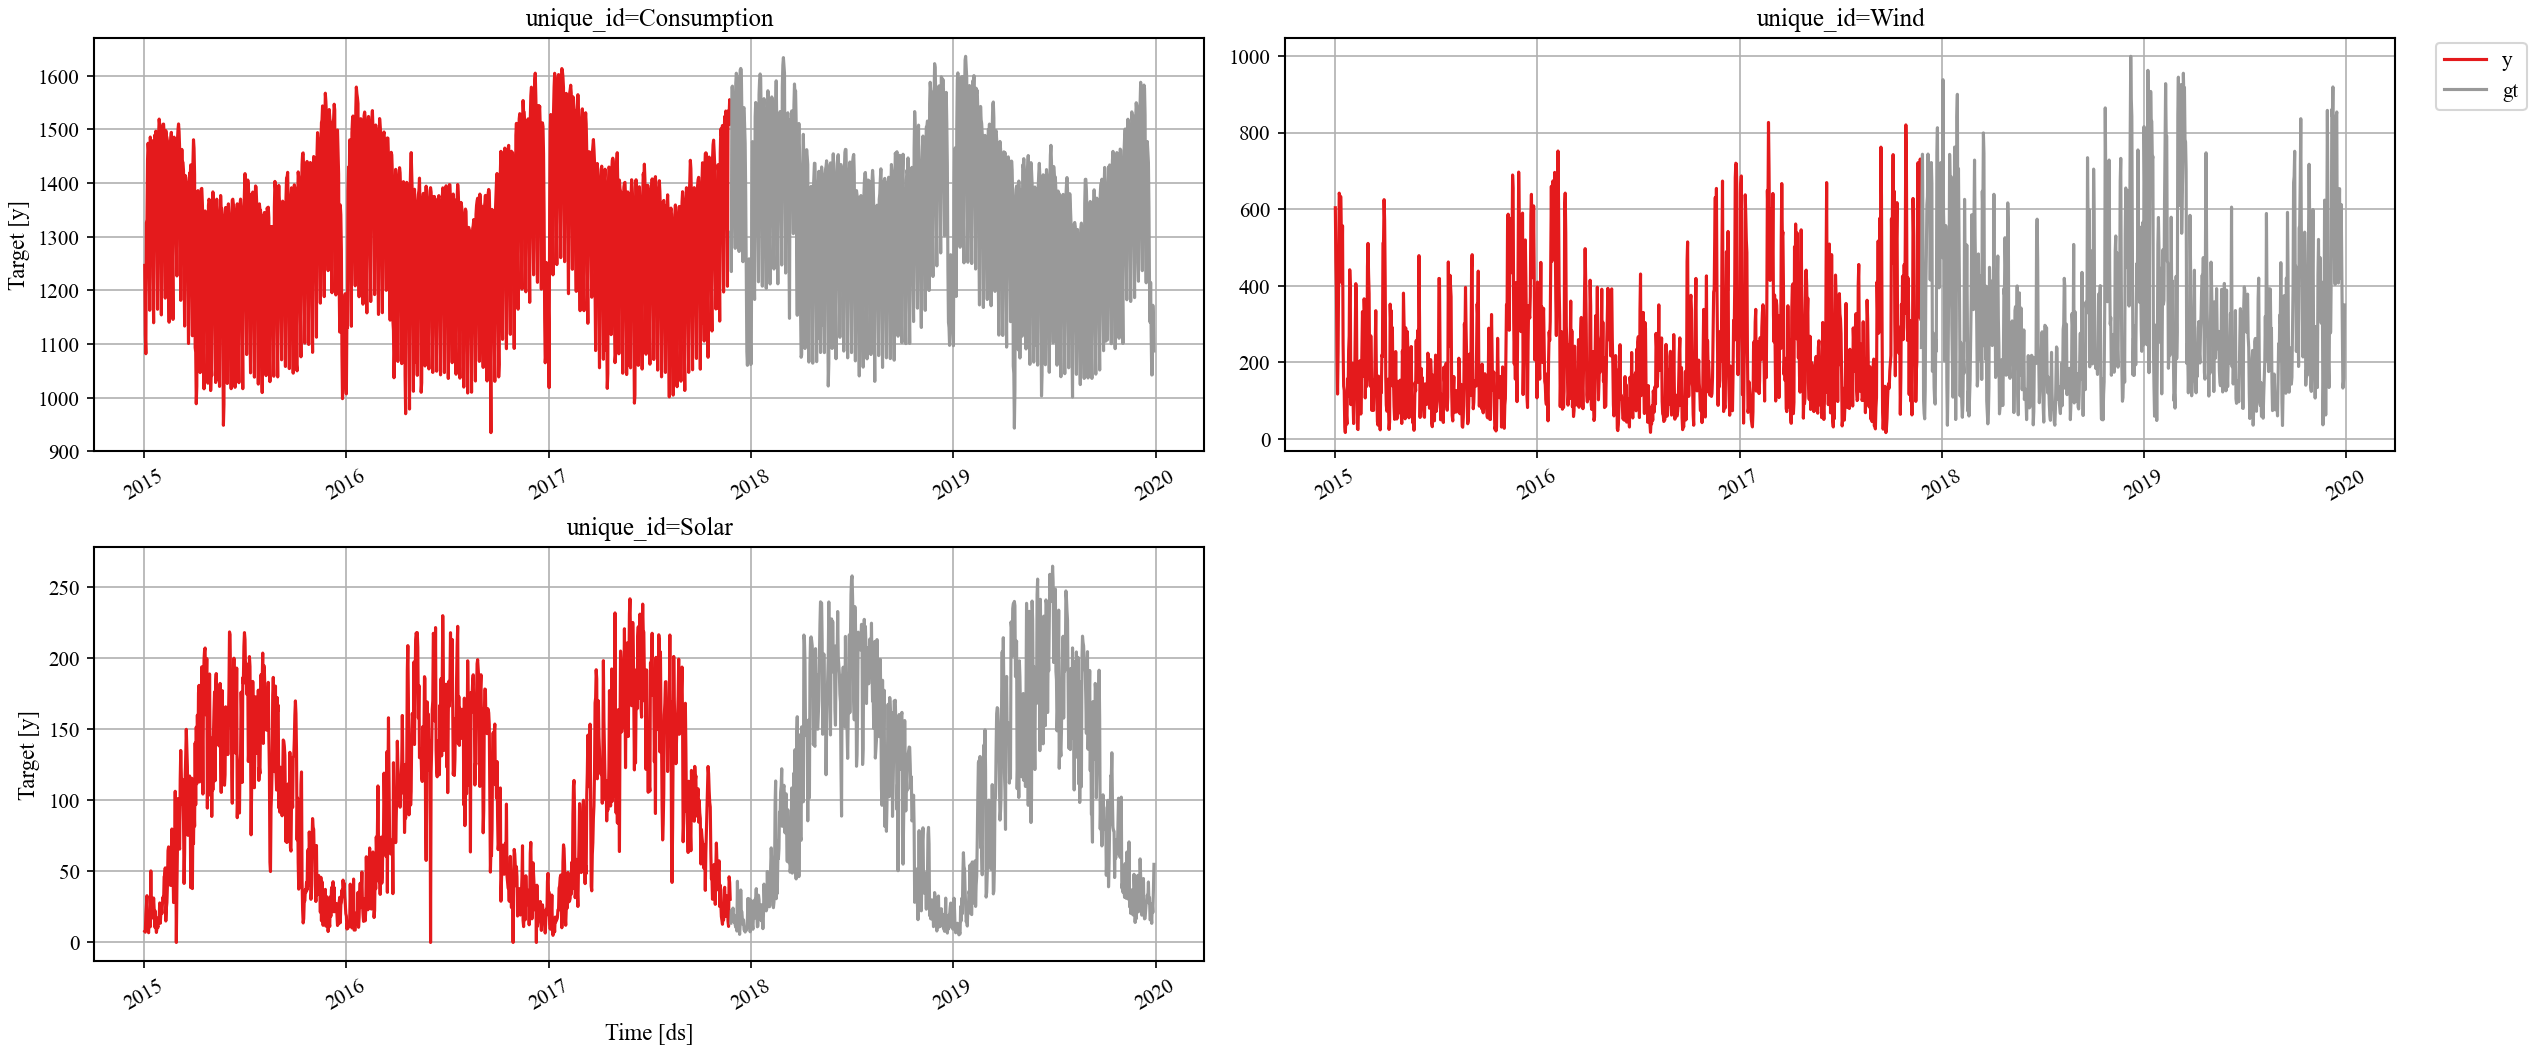

In [38]:
y = df_.resample('D').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]



ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq

# SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON = [7,365] # 53 недели в году

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [39]:
models = [TSProphet(freq=FREQ,     
                    weekly_seasonality=True,
                    yearly_seasonality=True,
                    alias='test_1' ),
          TSProphet(freq=FREQ, 
                       seasonality_mode='additive',
                        seasonality_prior_scale=0.9,  # уменьшили — сезонность будет мягче
                        changepoint_prior_scale=0.01,  # уменьшили — тренд будет мягче
                        add_country_holidays='GE',
                        weekly_seasonality=True,
                        yearly_seasonality=True)]

sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

13:01:12 - cmdstanpy - INFO - Chain [1] start processing
13:01:12 - cmdstanpy - INFO - Chain [1] done processing
13:01:12 - cmdstanpy - INFO - Chain [1] start processing
13:01:12 - cmdstanpy - INFO - Chain [1] done processing
13:01:13 - cmdstanpy - INFO - Chain [1] start processing
13:01:13 - cmdstanpy - INFO - Chain [1] done processing
13:01:13 - cmdstanpy - INFO - Chain [1] start processing
13:01:13 - cmdstanpy - INFO - Chain [1] done processing
13:01:14 - cmdstanpy - INFO - Chain [1] start processing
13:01:14 - cmdstanpy - INFO - Chain [1] done processing
13:01:14 - cmdstanpy - INFO - Chain [1] start processing
13:01:14 - cmdstanpy - INFO - Chain [1] done processing


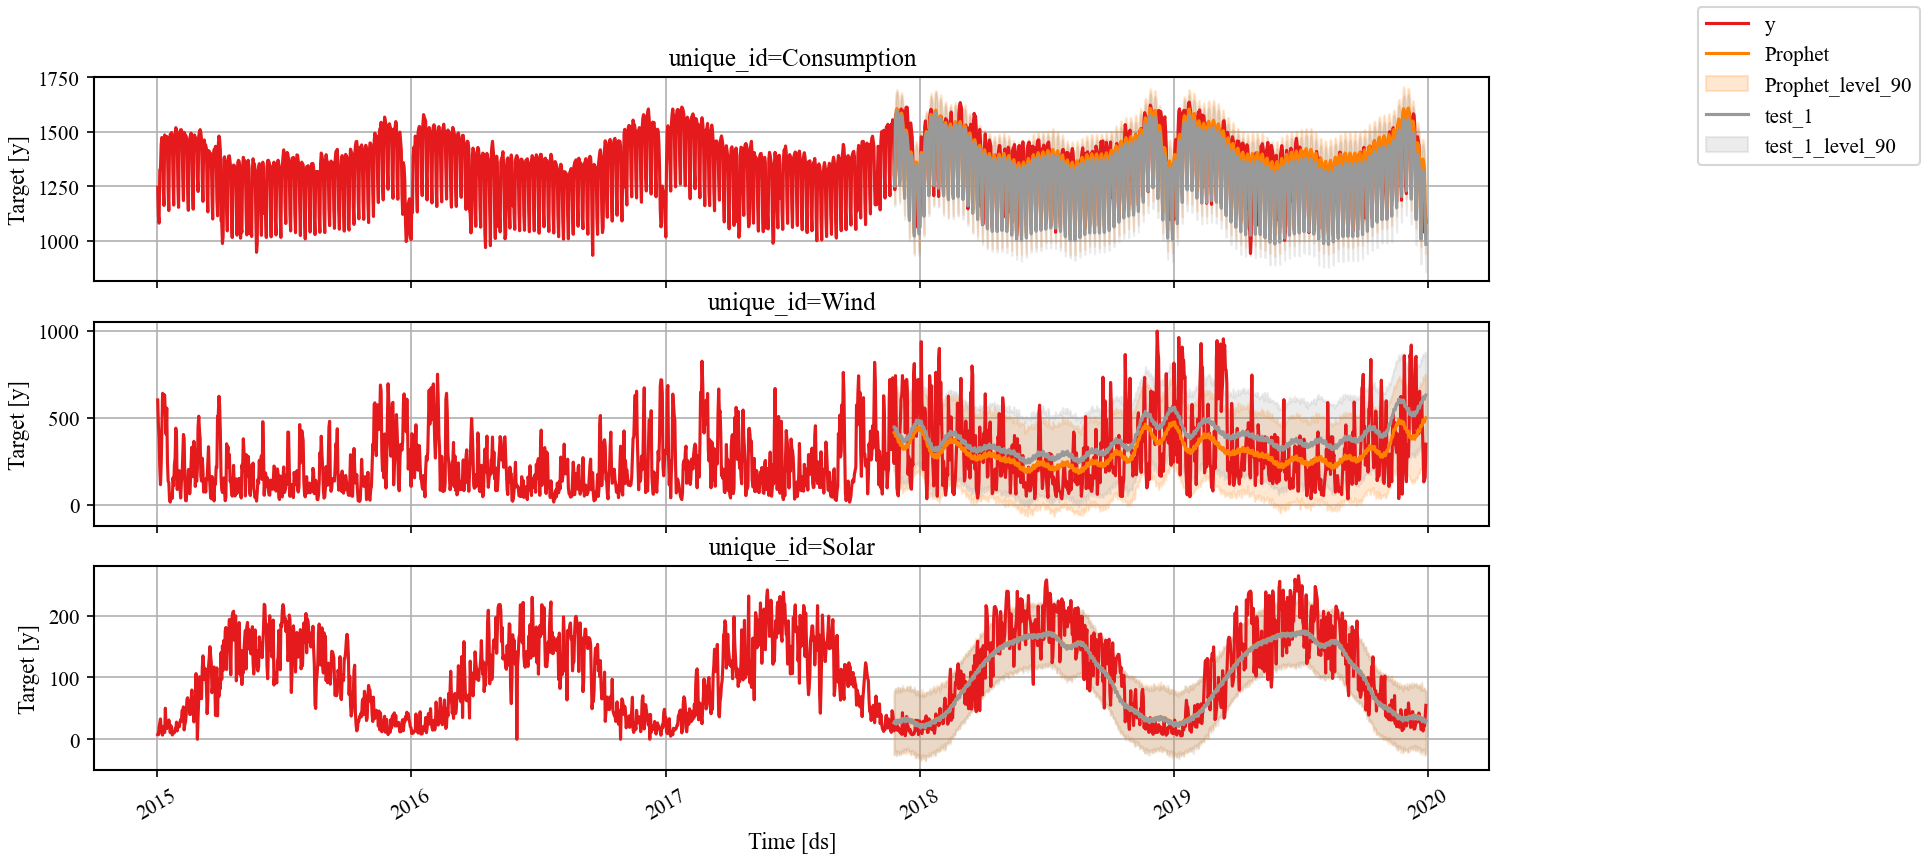

In [40]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], levels=LEVELS[1:])